# Zonificación de irradiancia en Nariño con funciones kernel
### Comparación de pipelines Escalador × Discretizador × Reductor × Modelo × Kernel sobre Landsat y MODIS

**Objetivo.** Clasificar la irradiancia solar del departamento de Nariño (Colombia) en zonas (baja, media‑baja,
media‑alta, alta) a partir de la posición y de las 7 bandas espectrales de los satélites Landsat y MODIS, comparando
de forma justa un conjunto de funciones kernel acopladas a tres modelos: **KSVC**, **KANN** (del repositorio
[magohector/fkernel](https://github.com/magohector/fkernel/tree/master/Experimentos)) y **KRidgeClassifier**
(desarrollado aquí).

| Punto | Contenido | Sección |
|---|---|---|
| 1 | Carga y exploración de los datasets Landsat y MODIS | §1 |
| 2 | Clases KSVC y KANN del repositorio (verificadas y vectorizadas) | §2 |
| 2b | `KRidgeClassifier`: RidgeClassifier con truco kernel | §3 |
| 3 | Campo de pipelines: 3 escaladores × 4 discretizadores × 2 reductores × 3 modelos × 9 kernels | §4 |
| 4 | Evaluación justa (Accuracy, F1, AUC, MCC), matrices de confusión, curvas ROC/PR | §5 |
| 5 | Despliegue: modelos exportados a `models/` para la aplicación web (ver `README.md`) | §6 |

**Organización del código.** Las celdas que empiezan por `%%writefile` escriben los módulos del paquete
`fkernel_lab/`. Así el código queda explicado aquí y la aplicación web importa exactamente el mismo código
(los modelos guardados con joblib se pueden cargar en el servidor).

Artículo de referencia: Pachajoa, Mora‑Paz y Mayorca‑Torres (2021), *Comparison of Kernel Functions in the
Classification of Irradiance Zones from Multispectral Satellite Images*, Rev. Fac. Ing. 30(58).

### Preparación del entorno
El notebook puede abrirse desde la raíz del repositorio o desde `notebooks/`; la primera celda sitúa el directorio
de trabajo en la raíz. Las etapas costosas (rejilla completa y sintonización) guardan sus resultados en `results/`
y se reutilizan si existen; cambie `RECALCULAR = True` para repetirlas desde cero.

**En Google Colab:** suba `irradiancia-kernel-app.zip` y ejecute antes una celda con
`!unzip -q irradiancia-kernel-app.zip` y `%cd irradiancia-kernel-app`. Así se aprovechan los resultados ya
calculados; si no, la rejilla completa se recalcula (unos 30–45 minutos). El código funciona con scikit-learn
1.6 (la versión de Colab) y 1.8. Para que los modelos exportados se puedan cargar en la aplicación web, la versión
de scikit-learn debe ser la misma en ambos sitios: si exporta desde Colab, ajuste `requirements.txt` a esa versión.

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
for d in ["fkernel_lab/original", "data", "models", "results"]:
    Path(d).mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

RECALCULAR = False   # True = repetir la rejilla y la sintonización aunque haya caché
SEED = 2021
import sklearn
print("Directorio de trabajo:", ROOT, "· scikit-learn", sklearn.__version__)

Directorio de trabajo: /home/claude/proj · scikit-learn 1.8.0


In [2]:
%%writefile fkernel_lab/__init__.py
"""Librería del proyecto: kernels, estimadores, discretizadores, pipelines y geo."""

Overwriting fkernel_lab/__init__.py


---
## 1. Datasets Landsat y MODIS

Los dos archivos provienen del repositorio del profesor. Cada fila es un punto de Nariño con:

| Variable | Significado |
|---|---|
| `latitude`, `longitude` | **Coordenadas proyectadas Web Mercator (EPSG:3857) en metros.** A pesar del nombre, `latitude` es la X (este) y `longitude` la Y (norte). |
| `band1` … `band7` | Bandas espectrales. En Landsat son reflectancias (0–1) y `band6` es la banda térmica (K); en MODIS son valores digitales escalados. |
| `value` | Irradiancia medida (variable objetivo, continua). |

Se descargan si no están en `data/`.

In [3]:
URL = "https://raw.githubusercontent.com/magohector/fkernel/master/Experimentos/{}_model.csv"
datasets = {}
for name in ["landsat", "modis"]:
    path = Path("data") / f"{name}_model.csv"
    if not path.exists():
        import urllib.request
        urllib.request.urlretrieve(URL.format(name), path)
    datasets[name] = pd.read_csv(path)
    datasets[name].attrs["name"] = name
    print(f"{name:8s} {datasets[name].shape[0]} filas × {datasets[name].shape[1]} columnas")

landsat, modis = datasets["landsat"], datasets["modis"]
display(landsat.head(3)); display(modis.head(3))

landsat  434 filas × 10 columnas
modis    445 filas × 10 columnas


,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0000,184950.0000,0.1051,0.0827,0.0528,0.3155,0.1326,296.1786,0.0446,203.4000
1,-8784900.0000,174600.0000,0.1048,0.0857,0.0535,0.2715,0.0902,295.9697,0.0273,198.3000
2,-8775000.0000,164700.0000,0.1035,0.0791,0.0489,0.2486,0.0786,296.8427,0.0221,203.1000


,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0000,184950.0000,3296.9031,4486.1233,3395.3201,3448.0070,4321.5153,3236.0248,2072.2050,203.4000
1,-8784900.0000,174600.0000,2723.5449,3882.3816,2847.1238,2902.1673,3775.9328,2743.9727,1732.7327,198.3000
2,-8775000.0000,169650.0000,3254.5484,4358.6138,3360.0565,3400.0736,4235.7833,3224.0447,2056.6963,199.1000


In [4]:
resumen = pd.concat({n: d.describe().T[["mean", "std", "min", "max"]] for n, d in datasets.items()}, axis=1)
display(resumen)
comunes = landsat.merge(modis, on=["latitude", "longitude"], suffixes=("_l", "_m"))
print(f"Puntos comunes a ambos satélites: {len(comunes)}; "
      f"misma irradiancia en todos ellos: {(comunes.value_l == comunes.value_m).all()}")
print("Valores faltantes:", {n: int(d.isna().sum().sum()) for n, d in datasets.items()})

landsat                                                modis  \
                   mean        std           min           max          mean   
latitude  -8670245.3917 56261.1876 -8789850.0000 -8554950.0000 -8669930.5618   
longitude   172098.0415 52784.2574    45000.0000   294750.0000   173032.5843   
band1            0.0954     0.0117        0.0632        0.1214     3278.9604   
band2            0.0804     0.0102        0.0474        0.1023     4504.2187   
band3            0.0540     0.0078        0.0311        0.0786     3383.7962   
band4            0.2889     0.0480        0.1561        0.4095     3415.4654   
band5            0.1350     0.0330        0.0545        0.2627     4397.3431   
band6          295.4710     2.2971      286.1487      302.2222     3207.8546   
band7            0.0512     0.0166        0.0177        0.1179     1970.0238   
value          209.8684    17.2562      188.5000      247.3000      210.1822   

                                                  
                 std           min           max  
latitude  56643.7268 -8789850.0000 -8554950.0000  
longitude 53040.0362    45000.0000   294750.0000  
band1       395.7099     1934.5634     4402.5890  
band2       349.1501     3161.6535     5296.8955  
band3       420.1949     1897.3258     4513.4726  
band4       395.1165     2024.8353     4525.7078  
band5       291.6354     3086.3605     5039.5117  
band6       215.4742     2409.2290     3700.4471  
band7       144.1029     1582.5161     2374.8385  
value        17.3444      188.5000      248.1000

Puntos comunes a ambos satélites: 424; misma irradiancia en todos ellos: True
Valores faltantes: {'landsat': 0, 'modis': 0}


Ambos satélites describen prácticamente la misma malla de puntos (424 comunes) con la misma irradiancia; lo que
cambia es la información espectral. Por eso tiene sentido entrenar y comparar modelos para cada satélite por
separado. No hay valores faltantes.

### Geolocalización
El módulo `geo.py` convierte EPSG:3857 → WGS84 (grados), interpola las bandas en puntos sin observación (IDW) y
construye la malla del mapa. Lo usará también la aplicación web.

In [5]:
%%writefile fkernel_lab/geo.py
"""Utilidades geoespaciales.

Las columnas del dataset se llaman ``latitude`` y ``longitude`` pero en
realidad contienen coordenadas proyectadas Web Mercator (EPSG:3857) en
metros: ``latitude`` es la X (este) y ``longitude`` es la Y (norte). Se
conservan esos nombres como variables de entrada del modelo y aquí se
convierten a grados WGS84 (EPSG:4326) para el mapa web.

Para clasificar un punto arbitrario del mapa hacen falta sus 7 bandas
espectrales, que solo se conocen en los puntos observados. ``SpectralField``
las estima por interpolación IDW (inverso de la distancia) a partir de los
vecinos más cercanos del mismo satélite.
"""
import numpy as np
from scipy.spatial import cKDTree

R = 6378137.0
BANDS = ["band1", "band2", "band3", "band4", "band5", "band6", "band7"]


def merc_to_lonlat(x, y):
    lon = np.degrees(np.asarray(x, float) / R)
    lat = np.degrees(np.arctan(np.sinh(np.asarray(y, float) / R)))
    return lon, lat


def lonlat_to_merc(lon, lat):
    x = np.radians(np.asarray(lon, float)) * R
    y = R * np.log(np.tan(np.pi / 4 + np.radians(np.asarray(lat, float)) / 2))
    return x, y


class SpectralField:
    """Interpolador IDW de las bandas de un satélite."""

    def __init__(self, df, k=8, power=2.0):
        self.xy = df[["latitude", "longitude"]].to_numpy(float)
        self.bands = df[BANDS].to_numpy(float)
        self.tree = cKDTree(self.xy)
        self.k = min(k, len(df))
        self.power = power

    def features_at(self, x, y):
        """Devuelve la matriz de entrada [x, y, band1..band7] y la distancia
        (m) a la observación más cercana."""
        pts = np.column_stack([np.atleast_1d(x), np.atleast_1d(y)]).astype(float)
        dist, idx = self.tree.query(pts, k=self.k)
        w = 1.0 / np.maximum(dist, 1.0) ** self.power
        exact = dist[:, 0] < 1.0
        w[exact] = 0.0
        w[exact, 0] = 1.0
        w /= w.sum(axis=1, keepdims=True)
        bands = np.einsum("nk,nkb->nb", w, self.bands[idx])
        return np.column_stack([pts, bands]), dist[:, 0]


class StudyGrid:
    """Malla regular (en metros) que cubre la zona de estudio. Solo se
    conservan celdas a menos de ``max_dist`` de alguna observación."""

    def __init__(self, frames, step=2000.0, max_dist=7500.0):
        xy = np.vstack([f[["latitude", "longitude"]].to_numpy(float) for f in frames])
        x0, y0 = xy.min(0) - step
        x1, y1 = xy.max(0) + step
        self.xs = np.arange(x0, x1 + step, step)
        self.ys = np.arange(y1, y0 - step, -step)  # de norte a sur (filas de imagen)
        gx, gy = np.meshgrid(self.xs, self.ys)
        dist, _ = cKDTree(xy).query(np.column_stack([gx.ravel(), gy.ravel()]))
        self.shape = gx.shape
        self.mask = (dist <= max_dist).reshape(self.shape)
        self.x = gx[self.mask]
        self.y = gy[self.mask]
        self.step = step

    def bounds_latlon(self):
        """[[lat_sur, lon_oeste], [lat_norte, lon_este]] para Leaflet."""
        h = self.step / 2
        lon0, lat0 = merc_to_lonlat(self.xs[0] - h, self.ys[-1] - h)
        lon1, lat1 = merc_to_lonlat(self.xs[-1] + h, self.ys[0] + h)
        return [[float(lat0), float(lon0)], [float(lat1), float(lon1)]]

    def to_image(self, values, fill=np.nan):
        img = np.full(self.shape, fill, dtype=float)
        img[self.mask] = values
        return img


# Paleta del notebook de regresión (azul -> verde -> amarillo -> rojo)
PALETTE = [(0, 0, 1), (0, 0.7, 0), (0, 1, 0), (0.9, 1, 0), (1, 0.7, 0), (1, 0.5, 0), (1, 0, 0)]


def irradiance_rgb(values, vmin, vmax):
    """Mapea irradiancia a RGB (0-255) con la paleta anterior."""
    t = np.clip((np.asarray(values, float) - vmin) / (vmax - vmin), 0, 1)
    pos = t * (len(PALETTE) - 1)
    i = np.minimum(pos.astype(int), len(PALETTE) - 2)
    f = (pos - i)[..., None]
    pal = np.asarray(PALETTE, float)
    rgb = pal[i] * (1 - f) + pal[i + 1] * f
    return (rgb * 255).round().astype(np.uint8)


def rgb_hex(rgb):
    return "#%02x%02x%02x" % tuple(int(v) for v in rgb)

Overwriting fkernel_lab/geo.py


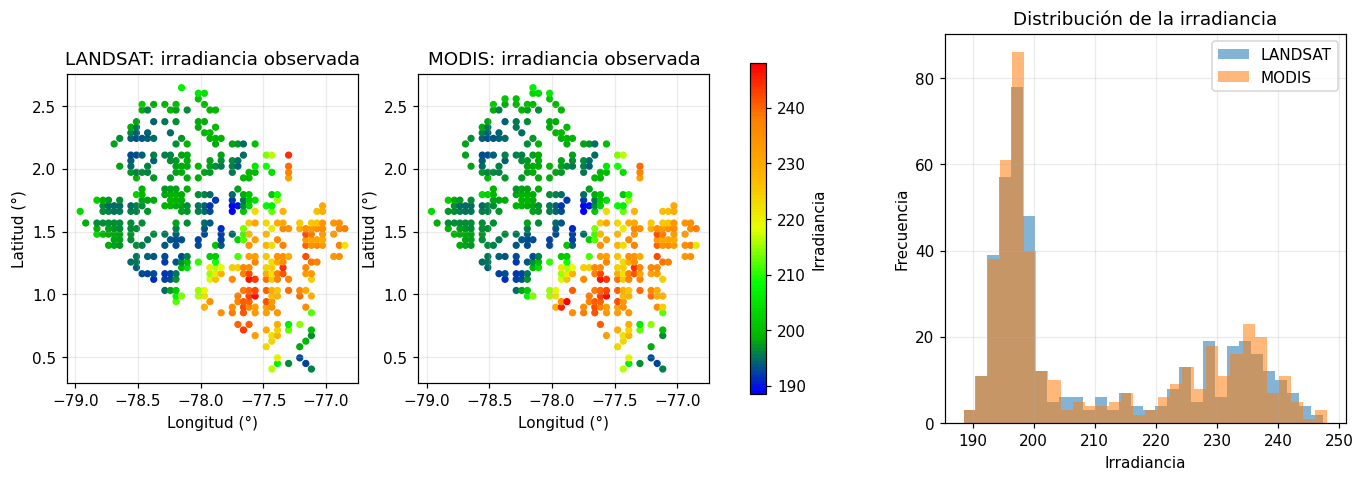

In [6]:
from fkernel_lab.geo import merc_to_lonlat, PALETTE

CMAP = LinearSegmentedColormap.from_list("irradiancia", PALETTE, N=100)  # paleta del notebook de regresión
vmin = min(d.value.min() for d in datasets.values()); vmax = max(d.value.max() for d in datasets.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1, 1, 1.1]})
for ax, (name, d) in zip(axes, datasets.items()):
    lon, lat = merc_to_lonlat(d.latitude, d.longitude)
    sc = ax.scatter(lon, lat, c=d.value, cmap=CMAP, s=14, vmin=vmin, vmax=vmax)
    ax.set(title=f"{name.upper()}: irradiancia observada", xlabel="Longitud (°)", ylabel="Latitud (°)")
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes[:2], label="Irradiancia", shrink=0.85)
for name, d in datasets.items():
    axes[2].hist(d.value, bins=30, alpha=0.55, label=name.upper())
axes[2].set(title="Distribución de la irradiancia", xlabel="Irradiancia", ylabel="Frecuencia")
axes[2].legend()
plt.show()

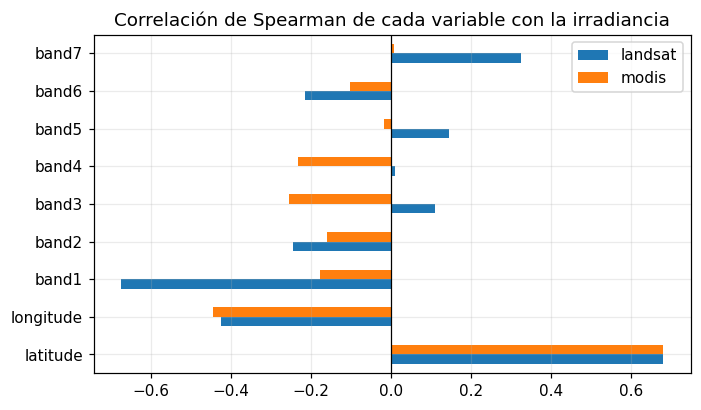

,latitude,longitude,band1,band2,band3,band4,band5,band6,band7
landsat,0.6809,-0.4265,-0.6760,-0.2467,0.1105,0.0105,0.1434,-0.2165,0.3240
modis,0.6803,-0.4455,-0.1783,-0.1597,-0.2565,-0.2340,-0.0170,-0.1021,0.0076


In [7]:
from scipy.stats import spearmanr
features = ["latitude", "longitude"] + [f"band{i}" for i in range(1, 8)]
corr = pd.DataFrame({n: [spearmanr(d[f], d.value)[0] for f in features] for n, d in datasets.items()},
                    index=features)
ax = corr.plot.barh(figsize=(7, 4), title="Correlación de Spearman de cada variable con la irradiancia")
ax.axvline(0, color="k", lw=0.8); plt.show()
display(corr.T)

**Observaciones.**
* La irradiancia es **bimodal**: una moda alrededor de 195 (costa pacífica, occidente, nubosa) y otra alrededor de 230
  (zona andina, oriente). Esto anticipa que la frontera entre zonas bajas y altas es fácil y que las zonas
  intermedias serán las difíciles y minoritarias.
* La posición (X‑este) y varias bandas están fuertemente correlacionadas con la irradiancia; en Landsat destaca la
  banda térmica `band6`. En MODIS casi todas las bandas se relacionan en sentido negativo (más reflectancia = más
  nubes = menos irradiancia).
* Las escalas de las variables son muy distintas (coordenadas ~10⁶, bandas ~10⁻¹ o ~10³), por eso el escalador
  forma parte del pipeline.

---
## 2. Clases KSVC y KANN del repositorio

Se usan las clases originales de `KSVM.py` y `KANN.py` (y las funciones de `KernelUtilities.py` de las que
dependen). El módulo siguiente las descarga de GitHub si no existen y las importa sin modificarlas.

In [8]:
%%writefile fkernel_lab/original/__init__.py
"""Clases originales del repositorio https://github.com/magohector/fkernel
(carpeta Experimentos, licencia GPL, autor Héctor Andrés Mora Paz).

Los archivos KSVM.py y KANN.py hacen ``from KernelUtilities import *``, así que
se añade esta carpeta al ``sys.path`` antes de importarlos. Si faltan, se
descargan desde GitHub.
"""
import os
import sys
import urllib.request

_HERE = os.path.dirname(os.path.abspath(__file__))
_BASE = "https://raw.githubusercontent.com/magohector/fkernel/master/Experimentos/"
for _name in ("KernelUtilities.py", "KSVM.py", "KANN.py"):
    _path = os.path.join(_HERE, _name)
    if not os.path.exists(_path):
        urllib.request.urlretrieve(_BASE + _name, _path)
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

import KernelUtilities  # noqa: E402,F401
from KSVM import KSVC  # noqa: E402
from KANN import KANNC  # noqa: E402

__all__ = ["KSVC", "KANNC", "KernelUtilities"]

Overwriting fkernel_lab/original/__init__.py


In [9]:
import inspect
from fkernel_lab.original import KSVC, KANNC, KernelUtilities as KU
print(inspect.getsource(KSVC.fit)[:1300], "...")
print(inspect.getsource(KANNC.fit)[:900], "...")

    def fit(self, X, y, sample_weight=None):
        
        if(self.kernel=="linear" or self.kernel== "poly" or self.kernel== "rbf"):
            super().fit(X,y)
            return self
        else:            
            if(self.kernel=="mrbf"):                  
                self.kernel=mrbf_kernel(degree=self.degree, gamma=self.gamma)                   
                super().fit(X,y)
                return self
            if(self.kernel=="hyperbolic"):                
                self.kernel=hyperbolic_kernel(self.gamma,self.coef0)                
                super().fit(X,y)
                return self 
            if(self.kernel=="triangle"):                
                self.kernel=triangle_kernel(self.gamma)                
                super().fit(X,y)
                return self 
            if(self.kernel=="radial_basic"):                
                self.kernel=radial_basic_kernel(self.degree, self.gamma)                
                super().f

**Cómo funcionan.**
* `KSVC` hereda de `sklearn.svm.SVC`. Con `linear`, `poly` o `rbf` delega en sklearn; con los kernels alternativos
  (`hyperbolic`, `triangle`, `radial_basic`, `rquadratic`, `can`, `tru`) reemplaza `self.kernel` por una función que
  construye la **matriz de Gram** con `proxy_kernel` y deja que SVC trabaje con ella.
* `KANNC` hereda de `MLPClassifier`. Transforma las entradas con una aproximación de **Nyström** del kernel
  elegido (un mapa explícito de características de dimensión 100) y entrena la red neuronal sobre ese mapa.

**Limitaciones encontradas al usarlas en un experimento grande y en una aplicación web.**
1. `proxy_kernel` calcula la matriz de Gram con un **doble bucle de Python**: con ~280 observaciones son ~78 000
   llamadas por ajuste y otras tantas por predicción, lo que hace inviable evaluar cientos de pipelines o pintar un mapa.
2. `fit` sustituye `self.kernel` por una **función anidada (clausura)**, que `pickle`/`joblib` no pueden serializar:
   el modelo no se podría guardar ni desplegar.
3. El valor por defecto `gamma='auto_deprecated'` ya no es válido en las versiones actuales de sklearn.
4. `KANNC` no ofrece `predict_proba` coherente con su mapa de Nyström (necesario para AUC y curvas).
5. Los parámetros de escala son absolutos (p. ej. `gamma=0.01`); como cada kernel usa la escala de forma distinta,
   un mismo valor favorece a unos kernels y perjudica a otros: **la comparación no sería justa**.

**Solución adoptada.** No se reescriben las clases: se **heredan**. `KSVCVec` y `KANNCVec` conservan el constructor,
`set_params`, `predict` y `mtransform` originales, y reutilizan el `fit` original con los kernels nativos. Solo se
sustituye el cálculo de la matriz de Gram de los kernels alternativos por una versión vectorizada y serializable
(`KernelFunction`), y se añade una **calibración por la mediana** de la escala de cada kernel.

### 2.1 Kernels vectorizados y calibración por la mediana
Con $s$ = distancia euclídea mediana entre observaciones de entrenamiento y $c$ = diferencia absoluta mediana por
coordenada, la escala se fija para que $k \approx 0.5$ a esa distancia típica:

| Kernel | Definición (Belanche) | Escala calibrada |
|---|---|---|
| rbf / mrbf | $e^{-\gamma\,\lVert x-y\rVert^2}$ | $\gamma=\ln 2/s^2$ |
| radial básico (ANOVA) | $\left(\sum_k e^{-\gamma(x_k-y_k)^2}\right)^m$ | $\gamma=\ln 2/c^2$ |
| triangular | $\max(0,\,1-\lVert x-y\rVert/a)$ | $a=2s$ |
| truncado | $\frac1d\sum_k \max(0,\,1-\lvert x_k-y_k\rvert/\gamma)$ | $\gamma=2c$ |
| cuadrático racional | $1-\lVert x-y\rVert^2/(\lVert x-y\rVert^2+c_0)$ | $c_0=s^2$ |
| polinómico / tangente hiperbólica | $(a\,x\cdot y+1)^m$ / $\tanh(a\,x\cdot y+b)$ | $a = 1/(d\,\mathrm{Var}(X))$ (como `gamma='scale'`) |
| Canberra | $1-\frac1d\sum_k \gamma\lvert x_k-y_k\rvert/(\lvert x_k\rvert+\lvert y_k\rvert)$ | $\gamma=1$ |
| lineal | $x\cdot y$ | — |

El parámetro `bandwidth` multiplica esa escala y es el que se sintoniza en la etapa 2.

In [10]:
%%writefile fkernel_lab/kernels.py
"""Funciones kernel de Belanche en forma matricial (vectorizada).

Las funciones de ``KernelUtilities.py`` del repositorio magohector/fkernel
calculan k(x, y) para UN par de vectores y construyen la matriz de Gram con un
doble bucle de Python. Aquí se reescribe la MISMA matemática para matrices
completas X (n x d) e Y (m x d), de modo que la matriz de Gram K(X, Y) se
obtiene con operaciones de NumPy.

Además, ``KernelFunction`` es una clase (no una clausura) y por tanto se puede
serializar con joblib/pickle: esto es lo que permite guardar los modelos y
desplegarlos en la aplicación web.

Calibración por la mediana
--------------------------
Cuando el parámetro de escala vale ``'median'`` se fija a partir de los datos
de entrenamiento para que el kernel valga 0.5 a la distancia mediana entre
observaciones. Así todos los kernels arrancan en una escala comparable (la
comparación es justa) y ``bandwidth`` actúa como multiplicador común que se
puede sintonizar después.
"""
import numpy as np

LN2 = np.log(2.0)

# Nombre corto -> descripción (se usa en el notebook y en la app web)
KERNEL_CATALOG = {
    "linear": "Lineal  k = x·y",
    "poly": "Polinómico  k = (a x·y + 1)^m",
    "rbf": "Gaussiano / MRBF  k = exp(-g Σ(x-y)^β)",
    "hyperbolic": "Tangente hiperbólica  k = tanh(a x·y + b)",
    "triangle": "Triangular  k = max(0, 1 - ||x-y||/a)",
    "radial_basic": "Radial básico (ANOVA)  k = (Σ exp(-g (x_k-y_k)^2))^m",
    "rquadratic": "Cuadrático racional  k = 1 - ||x-y||²/(||x-y||² + c)",
    "canberra": "Canberra  k = 1 - (1/d) Σ g|x_k-y_k|/(|x_k|+|y_k|)",
    "truncated": "Truncado  k = (1/d) Σ max(0, 1 - |x_k-y_k|/g)",
}
KERNELS = tuple(KERNEL_CATALOG)


# ---------------------------------------------------------------------------
# Piezas básicas de distancia
# ---------------------------------------------------------------------------
def _sq_dists(X, Y):
    """||x_i - y_j||² sin crear el tensor n x m x d."""
    xx = np.einsum("ij,ij->i", X, X)[:, None]
    yy = np.einsum("ij,ij->i", Y, Y)[None, :]
    return np.maximum(xx + yy - 2.0 * X @ Y.T, 0.0)


def _coord_diffs(X, Y):
    """Tensor de diferencias coordenada a coordenada (n x m x d)."""
    return X[:, None, :] - Y[None, :, :]


def _chunked(func, X, Y, max_cells=4_000_000):
    """Evalúa func(Xc, Y) por bloques para acotar memoria en kernels que
    necesitan el tensor n x m x d (radial básico, canberra, truncado, mrbf)."""
    per_row = max(1, Y.shape[0] * max(1, X.shape[1]))
    step = max(1, max_cells // per_row)
    if X.shape[0] <= step:
        return func(X, Y)
    return np.vstack([func(X[i:i + step], Y) for i in range(0, X.shape[0], step)])


# ---------------------------------------------------------------------------
# Kernels en forma matricial (misma definición que KernelUtilities.py)
# ---------------------------------------------------------------------------
def k_linear(X, Y, **_):
    return X @ Y.T


def k_poly(X, Y, degree=2, gamma=0.01, **_):
    return (gamma * (X @ Y.T) + 1.0) ** degree


def k_mrbf(X, Y, degree=2, gamma=0.01, **_):
    if degree == 2:  # caso gaussiano: no hace falta el tensor
        return np.exp(-gamma * _sq_dists(X, Y))

    def f(A, B):
        return np.exp(-np.sum(gamma * _coord_diffs(A, B) ** degree, axis=2))
    return _chunked(f, X, Y)


def k_hyperbolic(X, Y, gamma=0.01, coef0=0.0, **_):
    return np.tanh(gamma * (X @ Y.T) + coef0)


def k_triangle(X, Y, gamma=0.01, **_):
    dist = np.sqrt(_sq_dists(X, Y))
    return np.where(dist <= gamma, 1.0 - dist / gamma, 0.0)


def k_radial_basic(X, Y, degree=2, gamma=0.01, **_):
    def f(A, B):
        return np.sum(np.exp(-gamma * _coord_diffs(A, B) ** 2), axis=2) ** degree
    return _chunked(f, X, Y)


def k_rquadratic(X, Y, coef0=0.1, **_):
    d2 = _sq_dists(X, Y)
    return 1.0 - d2 / (d2 + coef0)


def k_canberra(X, Y, gamma=1.0, **_):
    d = X.shape[1]

    def f(A, B):
        num = gamma * np.abs(_coord_diffs(A, B))
        den = np.abs(A)[:, None, :] + np.abs(B)[None, :, :]
        with np.errstate(divide="ignore", invalid="ignore"):
            r = num / den
        r[~np.isfinite(r)] = 0.0  # el original descarta los NaN (0/0)
        return 1.0 - r.sum(axis=2) / d
    return _chunked(f, X, Y)


def k_truncated(X, Y, gamma=0.01, **_):
    d = X.shape[1]

    def f(A, B):
        val = 1.0 - np.abs(_coord_diffs(A, B)) / gamma
        return np.where(val > 0, val, 0.0).sum(axis=2) / d
    return _chunked(f, X, Y)


_MATRIX_KERNELS = {
    "linear": k_linear, "poly": k_poly, "rbf": k_mrbf, "mrbf": k_mrbf,
    "hyperbolic": k_hyperbolic, "triangle": k_triangle,
    "radial_basic": k_radial_basic, "rquadratic": k_rquadratic,
    "canberra": k_canberra, "can": k_canberra,
    "truncated": k_truncated, "tru": k_truncated,
}
# Alias usados por las clases originales KSVC / KANNC
ORIGINAL_NAMES = {"canberra": "can", "truncated": "tru"}


# ---------------------------------------------------------------------------
# Heurística de la mediana
# ---------------------------------------------------------------------------
def median_statistics(X, max_points=300, random_state=0):
    """Distancia euclídea mediana, diferencia absoluta mediana por coordenada
    y 'escala' tipo sklearn (1 / (d · var(X)))."""
    X = np.asarray(X, dtype=float)
    if X.shape[0] > max_points:
        idx = np.random.default_rng(random_state).choice(X.shape[0], max_points, replace=False)
        X = X[idx]
    iu = np.triu_indices(X.shape[0], k=1)
    dist = np.sqrt(_sq_dists(X, X))[iu]
    dist = dist[dist > 0]
    coord = np.abs(_coord_diffs(X, X))[iu].ravel()
    coord = coord[coord > 0]
    var = X.var()
    return {
        "median_dist": float(np.median(dist)) if dist.size else 1.0,
        "median_coord": float(np.median(coord)) if coord.size else 1.0,
        "scale": float(1.0 / (X.shape[1] * var)) if var > 0 else 1.0,
    }


def calibrate(name, stats, bandwidth=1.0):
    """Devuelve (gamma, coef0) calibrados para que k ≈ 0.5 a la distancia
    mediana. ``bandwidth`` > 1 ensancha el kernel (más suave)."""
    s, c, sc = stats["median_dist"], stats["median_coord"], stats["scale"]
    b = float(bandwidth)
    if name in ("rbf", "mrbf"):
        return LN2 / (b * s) ** 2, None
    if name == "radial_basic":
        return LN2 / (b * c) ** 2, None
    if name == "triangle":
        return 2.0 * b * s, None
    if name in ("truncated", "tru"):
        return 2.0 * b * c, None
    if name == "rquadratic":
        return None, (b * s) ** 2
    if name in ("poly", "hyperbolic"):
        return sc / b, None
    if name in ("canberra", "can"):
        return min(1.0, 1.0 / b), None  # gamma ∈ (0, 1]
    return None, None


class KernelFunction:
    """Kernel serializable que devuelve la matriz de Gram K(X, Y).

    Parámetros
    ----------
    name : nombre del kernel (ver ``KERNEL_CATALOG``)
    degree, gamma, coef0 : mismos significados que en KernelUtilities.py.
        ``gamma='median'`` (o coef0 en rquadratic) activa la calibración.
    bandwidth : multiplicador de la escala calibrada.
    """

    def __init__(self, name="rbf", degree=2, gamma="median", coef0=0.0, bandwidth=1.0):
        if name not in _MATRIX_KERNELS:
            raise ValueError(f"Kernel desconocido: {name!r}")
        self.name = name
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.bandwidth = bandwidth

    # -- ajuste de la escala ------------------------------------------------
    def fit(self, X):
        self.gamma_, self.coef0_ = self.gamma, self.coef0
        auto = isinstance(self.gamma, str) or (self.name == "rquadratic" and isinstance(self.coef0, str))
        if auto:
            g, c = calibrate(self.name, median_statistics(X), self.bandwidth)
            if g is not None and isinstance(self.gamma, str):
                self.gamma_ = g
            if c is not None:
                self.coef0_ = c
        if isinstance(self.gamma_, str):  # kernels sin gamma (lineal, rq)
            self.gamma_ = 0.01
        if isinstance(self.coef0_, str):
            self.coef0_ = 0.1 if self.name == "rquadratic" else 0.0
        return self

    def params_(self):
        return {"degree": self.degree, "gamma": float(self.gamma_), "coef0": float(self.coef0_)}

    # -- evaluación ---------------------------------------------------------
    def __call__(self, X, Y):
        if not hasattr(self, "gamma_"):
            self.fit(X)
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)
        K = _MATRIX_KERNELS[self.name](X, Y, **self.params_())
        return np.nan_to_num(K, nan=0.0, posinf=0.0, neginf=0.0)

    def __repr__(self):
        extra = ""
        if hasattr(self, "gamma_"):
            extra = f", gamma_={self.gamma_:.4g}, coef0_={self.coef0_:.4g}"
        return f"KernelFunction({self.name!r}, bandwidth={self.bandwidth}{extra})"

Overwriting fkernel_lab/kernels.py


**Verificación:** la versión matricial debe reproducir exactamente `proxy_kernel` del repositorio.

In [11]:
from fkernel_lab.kernels import KernelFunction, KERNEL_CATALOG
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(landsat[features].values)[:120]
originales = {"poly": KU.polynomial, "rbf": KU.mrbf, "hyperbolic": KU.hyperbolic, "triangle": KU.triangle,
              "radial_basic": KU.radial_basic, "rquadratic": KU.rquadratic,
              "canberra": KU.canberra, "truncated": KU.truncated}
filas = []
for name, f in originales.items():
    p = dict(degree=2, gamma=0.7, coef0=0.3)
    t0 = time.perf_counter(); A = np.nan_to_num(KU.proxy_kernel(Xs, Xs, f, **p)); t1 = time.perf_counter()
    B = KernelFunction(name, **p).fit(Xs)(Xs, Xs); t2 = time.perf_counter()
    filas.append({"kernel": name, "error_max_abs": np.abs(A - B).max(),
                  "t_original_ms": 1000 * (t1 - t0), "t_vectorizado_ms": 1000 * (t2 - t1),
                  "aceleración": (t1 - t0) / (t2 - t1)})
display(pd.DataFrame(filas).set_index("kernel"))

,error_max_abs,t_original_ms,t_vectorizado_ms,aceleración
kernel,,,,
poly,0.0000,19.9963,0.1833,109.1188
rbf,0.0000,87.4341,0.3416,255.9381
hyperbolic,0.0000,32.0613,0.1868,171.6537
triangle,0.0000,33.5585,0.4299,78.0679
radial_basic,0.0000,77.2985,2.0460,37.7806
rquadratic,0.0000,40.0438,0.2688,148.9543
canberra,0.0000,115.9691,1.5239,76.0999
truncated,0.0000,107.2407,1.1907,90.0634


Las diferencias son del orden del error de redondeo (el triangular llega a 1e‑7 por la raíz cuadrada de distancias
casi nulas) y el cálculo es cientos de veces más rápido.

### 2.2 KSVCVec y KANNCVec

In [12]:
%%writefile fkernel_lab/estimators.py
"""Estimadores kernel para clasificación de irradiancia.

* ``KSVCVec``  -> hereda de ``KSVC`` (KSVM.py original).
* ``KANNCVec`` -> hereda de ``KANNC`` (KANN.py original).
(``KRidgeClassifier`` está en ``kridge.py``.)

Las dos primeras conservan el constructor, ``set_params``, ``predict`` y
``mtransform`` de las clases originales y reutilizan su ``fit`` cuando el kernel
es nativo de sklearn. Para los kernels alternativos sustituyen las clausuras
de ``KernelUtilities`` (doble bucle de Python y no serializables) por
``KernelFunction``, que calcula la misma matriz de Gram de forma vectorizada y
se puede guardar con joblib. En el notebook se comprueba numéricamente que las
predicciones coinciden con las de las clases originales.
"""
import numpy as np
from scipy import linalg
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from .kernels import KernelFunction
from .original import KANNC, KSVC

NATIVE_SVC = ("linear", "poly", "rbf")  # los que KSVC delega en sklearn


def _kernel_name(kernel):
    return kernel.name if isinstance(kernel, KernelFunction) else kernel


# ---------------------------------------------------------------------------
# KSVC vectorizado
# ---------------------------------------------------------------------------
class KSVCVec(KSVC):
    """KSVC del repositorio + kernels vectorizados/serializables."""

    def __init__(self, C=1.0, kernel="rbf", degree=2, gamma="median", coef0=0.0,
                 bandwidth=1.0, shrinking=True, probability=False, tol=1e-3,
                 cache_size=200, class_weight=None, verbose=False, max_iter=-1,
                 decision_function_shape="ovr", random_state=None):
        super().__init__(C=C, kernel=kernel, degree=degree, gamma=gamma, coef0=coef0,
                         shrinking=shrinking, probability=probability, tol=tol,
                         cache_size=cache_size, class_weight=class_weight,
                         verbose=verbose, max_iter=max_iter,
                         decision_function_shape=decision_function_shape,
                         random_state=random_state)
        self.bandwidth = bandwidth

    def fit(self, X, y, sample_weight=None):
        X = np.asarray(X, dtype=float)
        name = _kernel_name(self.kernel)
        self.kernel_name_ = name
        user_gamma = self.gamma
        kf = KernelFunction(name, self.degree, self.gamma, self.coef0, self.bandwidth).fit(X)
        try:
            if name in NATIVE_SVC:
                # Camino ORIGINAL: KSVC.fit delega en SVC (gamma ya numérico)
                self.kernel = name
                self.gamma = kf.gamma_ if name != "linear" else "scale"
                KSVC.fit(self, X, y)
            else:
                # Kernel alternativo: callable Gram vectorizado y serializable
                self.kernel = kf
                self.gamma = "scale"  # sklearn lo ignora con kernels callable
                SVC.fit(self, X, y, sample_weight=sample_weight)
        finally:
            self.gamma = user_gamma
        self.kernel_params_ = kf.params_()
        return self


# ---------------------------------------------------------------------------
# Aproximación de Nyström con kernel vectorizado
# ---------------------------------------------------------------------------
class KernelNystroem(TransformerMixin, BaseEstimator):
    """Equivalente a ``sklearn.kernel_approximation.Nystroem`` (misma
    normalización U S^-1/2 V) pero usando ``KernelFunction`` matricial."""

    def __init__(self, kernel=None, n_components=100, random_state=None):
        self.kernel = kernel
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.kernel_ = self.kernel if self.kernel is not None else KernelFunction("rbf")
        self.kernel_.fit(X)
        n = min(self.n_components, X.shape[0])
        rng = np.random.RandomState(self.random_state)
        idx = rng.permutation(X.shape[0])[:n]
        self.components_ = X[idx]
        K = self.kernel_(self.components_, self.components_)
        U, S, V = linalg.svd(K)
        S = np.maximum(S, 1e-12)
        self.normalization_ = np.dot(U / np.sqrt(S), V)
        return self

    def transform(self, X):
        K = self.kernel_(np.asarray(X, dtype=float), self.components_)
        return K @ self.normalization_.T


# ---------------------------------------------------------------------------
# KANN vectorizado
# ---------------------------------------------------------------------------
class KANNCVec(KANNC):
    """KANNC del repositorio (MLP sobre un mapa de Nyström) con kernels
    vectorizados, ``predict_proba`` coherente y serialización."""

    def __init__(self, hidden_layer_sizes=(100,), activation="identity", solver="adam",
                 alpha=0.0001, learning_rate_init=0.001, max_iter=200, random_state=None,
                 tol=1e-4, early_stopping=True, validation_fraction=0.1,
                 n_iter_no_change=10, kernel="rbf", degree=2, gamma="median",
                 coef0=0.0, bandwidth=1.0, n_components=100):
        super().__init__(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                         solver=solver, alpha=alpha, learning_rate_init=learning_rate_init,
                         max_iter=max_iter, random_state=random_state, tol=tol,
                         early_stopping=early_stopping,
                         validation_fraction=validation_fraction,
                         n_iter_no_change=n_iter_no_change, kernel=kernel,
                         degree=degree, gamma=gamma, coef0=coef0)
        self.bandwidth = bandwidth
        self.n_components = n_components

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        self.kernel_name_ = self.kernel
        if self.kernel == "linear":
            return KANNC.fit(self, X, y)  # camino original sin mapa kernel
        kf = KernelFunction(self.kernel, self.degree, self.gamma, self.coef0, self.bandwidth)
        self.feature_map_nystroem = KernelNystroem(kf, self.n_components, self.random_state)
        Z = self.feature_map_nystroem.fit_transform(X)
        MLPClassifier.fit(self, Z, y)
        self.isfit = True
        self.kernel_params_ = kf.params_()
        return self

    # predict() y mtransform() se heredan tal cual de KANNC
    def predict_proba(self, X):
        return MLPClassifier.predict_proba(self, self.mtransform(np.asarray(X, dtype=float)))

Overwriting fkernel_lab/estimators.py


**Verificación:** con los mismos hiperparámetros, las clases heredadas deben predecir exactamente lo mismo que las originales.

In [13]:
from fkernel_lab.estimators import KSVCVec, KANNCVec, KernelNystroem
from fkernel_lab.kernels import ORIGINAL_NAMES
from sklearn.kernel_approximation import Nystroem
import joblib, io

y_demo = pd.qcut(landsat.value, 4, labels=False).values[:120]
filas = []
for name in ["rbf", "poly", "hyperbolic", "triangle", "radial_basic", "rquadratic", "canberra", "truncated"]:
    kw = dict(C=10, degree=2, gamma=0.3, coef0=0.5)
    orig = KSVC(kernel=ORIGINAL_NAMES.get(name, name), **kw).fit(Xs, y_demo)
    vec = KSVCVec(kernel=name, **kw).fit(Xs, y_demo)
    buf = io.BytesIO(); joblib.dump(vec, buf); buf.seek(0); vec2 = joblib.load(buf)
    filas.append({"kernel": name,
                  "coincidencia_predicciones": (orig.predict(Xs) == vec.predict(Xs)).mean(),
                  "dif_max_decision": np.abs(orig.decision_function(Xs) - vec.decision_function(Xs)).max(),
                  "serializable_joblib": bool((vec2.predict(Xs) == vec.predict(Xs)).all())})
display(pd.DataFrame(filas).set_index("kernel"))

ny = Nystroem(kernel=KU.c_mrbf_kernel(degree=2, gamma=0.3), n_components=40, random_state=0).fit(Xs)
kn = KernelNystroem(KernelFunction("rbf", 2, 0.3), 40, 0).fit(Xs)
print("Nyström original vs vectorizado, diferencia máxima:", np.abs(ny.transform(Xs) - kn.transform(Xs)).max())
kann = KANNCVec(kernel="rquadratic", max_iter=300, random_state=0).fit(Xs, y_demo)
print("KANNCVec: predict_proba", kann.predict_proba(Xs[:2]).round(3).tolist())

,coincidencia_predicciones,dif_max_decision,serializable_joblib
kernel,,,
rbf,1.0000,0.0000,True
poly,1.0000,0.0000,True
hyperbolic,1.0000,0.0000,True
triangle,1.0000,0.0002,True
radial_basic,1.0000,0.0000,True
rquadratic,1.0000,0.0000,True
canberra,1.0000,0.0000,True
truncated,1.0000,0.0000,True


Nyström original vs vectorizado, diferencia máxima: 1.3655743202889425e-14
KANNCVec: predict_proba [[0.363, 0.308, 0.329], [0.378, 0.305, 0.317]]


---
## 3. KRidgeClassifier: RidgeClassifier con truco kernel

`RidgeClassifier` convierte cada clase en una columna con +1/−1 y ajusta una regresión Ridge multisalida; la clase
predicha es la columna con mayor puntuación. En su forma primal busca $W$ con
$\min_W \lVert Y - XW\rVert^2 + \alpha\lVert W\rVert^2$, lo que solo produce fronteras **lineales**.

**Truco kernel.** Por el teorema del representante, la solución óptima en el espacio de características es
$w=\sum_i \alpha_i\,\phi(x_i)$, así que el modelo solo necesita productos escalares
$k(x_i,x_j)=\langle\phi(x_i),\phi(x_j)\rangle$, es decir, la matriz de Gram $K$. Con pesos de muestra $S$
(para `class_weight`) y un intercepto no penalizado:

$$
\min_{\alpha}\ \sum_i s_i\,\lVert y_i - f(x_i)\rVert^2 + \alpha\,\boldsymbol\alpha^\top K\boldsymbol\alpha
\quad\Longrightarrow\quad
(\tilde K + \alpha\,S^{-1})\,\boldsymbol\alpha = \tilde Y ,
$$

donde $\tilde K$ es la matriz de Gram **centrada** en el espacio de Hilbert y $\tilde Y$ los objetivos centrados.
La función de decisión es $f(x)=\tilde k(x)^\top\boldsymbol\alpha + \bar y$ y la predicción es $\arg\max f(x)$.

**Decisiones de implementación.**
* Hereda de `RidgeClassifier`: reutiliza su codificación de etiquetas (`LabelBinarizer` con ±1), su `class_weight` y su
  método `predict` (que llama a nuestra `decision_function`).
* Se resuelve el sistema simétrico equivalente $(S^{1/2}\tilde K S^{1/2}+\alpha I)\beta=S^{1/2}\tilde Y$; si el kernel no
  es definido positivo (tangente hiperbólica, Canberra, truncado) se usa mínimos cuadrados.
* Usa los mismos 9 kernels y la misma calibración que KSVC y KANN, lo que hace la comparación homogénea.

In [14]:
%%writefile fkernel_lab/kridge.py
"""KRidgeClassifier: RidgeClassifier de scikit-learn extendido con el truco
kernel (formulación dual de la regresión Ridge)."""
import numpy as np
from scipy import linalg
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y

from .kernels import KernelFunction


class KRidgeClassifier(RidgeClassifier):
    """Clasificador Ridge kernelizado.

    RidgeClassifier codifica las clases como +1/-1 (una columna por clase) y
    resuelve una regresión Ridge multisalida. Con el truco kernel el vector de
    pesos vive en el espacio de Hilbert, w = Σ α_i φ(x_i), y el problema

        min_α  Σ_i s_i ||y_i - f(x_i)||² + alpha · αᵀ K α

    tiene solución cerrada (K̃ + alpha · S⁻¹) α = Ỹ, donde K̃ es la matriz de
    Gram centrada (el intercepto no se penaliza), S son los pesos de muestra
    (``class_weight``) e Ỹ los objetivos centrados. La predicción es
    f(x) = k̃(x)ᵀ α + ȳ y la clase es argmax f(x), exactamente como en
    RidgeClassifier: por eso ``predict`` se HEREDA sin cambios.
    """

    def __init__(self, alpha=1.0, kernel="rbf", degree=2, gamma="median", coef0=1.0,
                 bandwidth=1.0, fit_intercept=True, class_weight=None):
        super().__init__(alpha=alpha, fit_intercept=fit_intercept, class_weight=class_weight)
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.bandwidth = bandwidth

    def fit(self, X, y, sample_weight=None):
        X, y = check_X_y(X, y, dtype=float)
        self.n_features_in_ = X.shape[1]
        # Misma codificación que RidgeClassifier: +1 clase correcta, -1 resto.
        # Debe llamarse _label_binarizer: RidgeClassifier lo usa en predict().
        self._label_binarizer = LabelBinarizer(pos_label=1, neg_label=-1)
        Y = self._label_binarizer.fit_transform(y).astype(float)
        classes = self._label_binarizer.classes_
        try:
            self.classes_ = classes  # sklearn >= 1.7: atributo normal
        except AttributeError:
            pass  # sklearn <= 1.6: classes_ es una propiedad de solo lectura
            #       que ya devuelve self._label_binarizer.classes_
        if len(classes) < 2:
            raise ValueError("KRidgeClassifier necesita al menos dos clases")

        w = np.ones(len(y)) if sample_weight is None else np.asarray(sample_weight, float)
        if self.class_weight is not None:
            w = w * compute_sample_weight(self.class_weight, y)
        w = w / w.mean()

        # Truco kernel: solo se necesita la matriz de Gram K(X, X)
        self.kernel_ = KernelFunction(self.kernel, self.degree, self.gamma, self.coef0,
                                      self.bandwidth).fit(X)
        K = self.kernel_(X, X)
        self.X_fit_ = X

        if self.fit_intercept:  # centrado (ponderado) en el espacio de Hilbert
            p = w / w.sum()
            self._p = p
            self._k_col_mean = K @ p                 # E_p[k(x_i, ·)]
            self._k_all_mean = float(p @ K @ p)
            self._y_offset = p @ Y
            Kc = K - self._k_col_mean[:, None] - self._k_col_mean[None, :] + self._k_all_mean
            Yc = Y - self._y_offset
        else:
            self._y_offset = np.zeros(Y.shape[1])
            Kc, Yc = K, Y

        # Sistema simétrico equivalente: (S½ K̃ S½ + alpha I) β = S½ Ỹ,  α = S½ β
        sq = np.sqrt(w)
        A = sq[:, None] * Kc * sq[None, :]
        A[np.diag_indices_from(A)] += self.alpha
        B = sq[:, None] * Yc
        try:
            beta = linalg.solve(A, B, assume_a="sym")
        except (linalg.LinAlgError, ValueError):
            beta = linalg.lstsq(A, B)[0]  # kernels no definidos positivos
        self.dual_coef_ = sq[:, None] * beta
        self.kernel_params_ = self.kernel_.params_()
        return self

    def decision_function(self, X):
        check_is_fitted(self, ["dual_coef_", "X_fit_"])
        X = check_array(X, dtype=float)
        K = self.kernel_(X, self.X_fit_)
        if self.fit_intercept:  # mismo centrado que en fit
            K = K - (K @ self._p)[:, None] - self._k_col_mean[None, :] + self._k_all_mean
        scores = K @ self.dual_coef_ + self._y_offset
        return scores.ravel() if scores.shape[1] == 1 else scores

    # predict() se hereda de RidgeClassifier: argmax de decision_function

Overwriting fkernel_lab/kridge.py


**Verificación 1:** con kernel lineal debe coincidir con `RidgeClassifier` (misma solución en forma primal y dual).

In [15]:
from fkernel_lab.kridge import KRidgeClassifier
from sklearn.linear_model import RidgeClassifier

filas = []
for a in [0.01, 0.1, 1, 10, 100]:
    r = RidgeClassifier(alpha=a).fit(Xs, y_demo)
    k = KRidgeClassifier(alpha=a, kernel="linear").fit(Xs, y_demo)
    filas.append({"alpha": a, "coincidencia": (r.predict(Xs) == k.predict(Xs)).mean(),
                  "dif_max_decision": np.abs(r.decision_function(Xs) - k.decision_function(Xs)).max()})
display(pd.DataFrame(filas))

,alpha,coincidencia,dif_max_decision
0,0.0100,1.0000,0.0000
1,0.1000,1.0000,0.0000
2,1.0000,1.0000,0.0000
3,10.0000,1.0000,0.0000
4,100.0000,1.0000,0.0000


**Verificación 2:** efecto del truco kernel en un problema 2D no lineal (dos lunas). Con kernel lineal la frontera es una recta; con los kernels alternativos se curva.

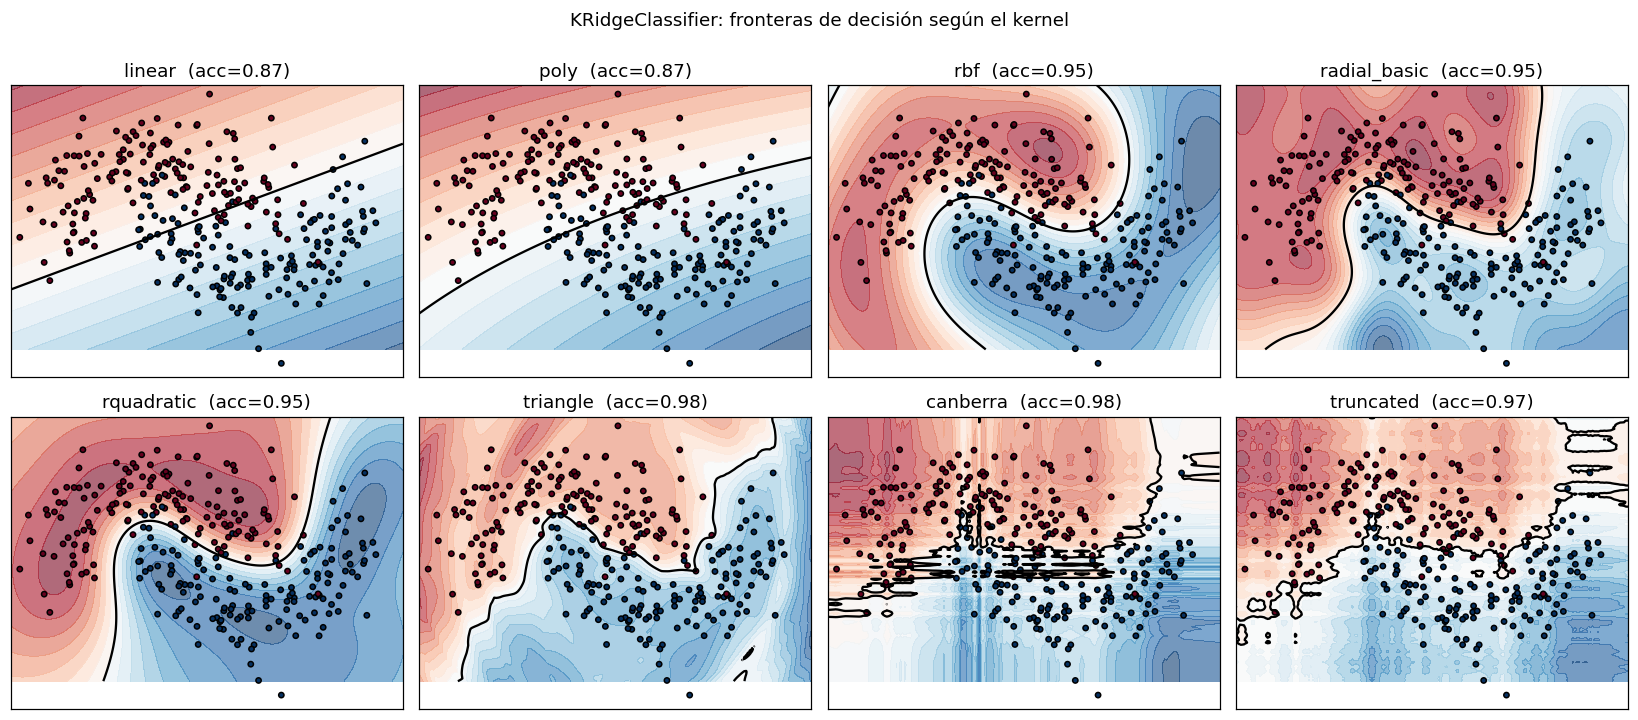

In [16]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(300, noise=0.25, random_state=SEED)
xx, yy = np.meshgrid(np.linspace(-1.6, 2.6, 200), np.linspace(-1.2, 1.7, 200))
grid2d = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, kname in zip(axes.ravel(), ["linear", "poly", "rbf", "radial_basic", "rquadratic", "triangle", "canberra", "truncated"]):
    clf = KRidgeClassifier(kernel=kname, alpha=0.1).fit(Xm, ym)
    Z = clf.decision_function(grid2d).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.5)
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="RdBu", edgecolor="k", s=12)
    ax.set_title(f"{kname}  (acc={clf.score(Xm, ym):.2f})"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("KRidgeClassifier: fronteras de decisión según el kernel", y=1.0); plt.tight_layout(); plt.show()

Los kernels de tipo RBF (rbf, radial básico, cuadrático racional) generan fronteras suaves. El triangular y el
truncado tienen soporte compacto: solo cuentan los vecinos cercanos, y la frontera es más local. Canberra divide por
|x_k|+|y_k|; cerca de los ejes (coordenadas próximas a 0) ese cociente cambia bruscamente y aparecen las franjas
rectas de la figura. Esto anticipa por qué el escalador influye tanto en los kernels por coordenada.

---
## 4. Campo de pipelines

Cada pipeline combina un elemento de cada grupo:

| Componente | Opciones | Actúa sobre |
|---|---|---|
| Escalador | `StandardScaler`, `MinMaxScaler`, `Normalizer` | X |
| Discretizador de la variable objetivo | Uniforme; clustering K‑Means, DBSCAN y jerárquico (Ward) | y |
| Reductor de dimensionalidad | PCA, LDA | X |
| Modelo | KSVC, KANN, KRidgeClassifier | X, y |
| Kernel | lineal, polinómico, rbf, tangente hiperbólica, triangular, radial básico, cuadrático racional, Canberra, truncado | modelo |

**Total: 3 × 4 × 2 × 3 × 9 = 648 pipelines por satélite (1 296 en total).**

### 4.1 Discretizador por umbrales
El discretizador transforma la irradiancia continua en zonas. En este trabajo **todos** los discretizadores producen
**umbrales de irradiancia**: el método (rangos iguales o clustering 1‑D) agrupa los valores de entrenamiento, los
grupos se ordenan y el corte entre dos zonas contiguas es el punto medio entre ellas. Ventajas:
* las clases son rangos interpretables (“zona media‑alta: 218–232”), lo que necesita la leyenda del mapa;
* los datos nuevos se clasifican sin volver a ejecutar el clustering (`np.digitize`), y el ruido de DBSCAN se asigna
  a su rango de forma natural;
* el discretizador se ajusta **solo con el entrenamiento** (no hay fuga de información hacia el holdout).

Se piden 4 zonas. DBSCAN no recibe el número de grupos: se barre `eps` y se elige la partición con ≤10 % de ruido
más cercana a 4 grupos, por lo que puede devolver menos zonas.

### 4.2 Reductor con igual dimensión
LDA produce como máximo *(n.º de clases − 1)* componentes. Para comparar PCA y LDA **en igualdad de condiciones**,
ambos proyectan al mismo número de dimensiones, min(clases − 1, variables); la diferencia está solo en el criterio de
proyección (varianza frente a separabilidad entre clases).

In [17]:
%%writefile fkernel_lab/preprocessing.py
"""Discretización de la irradiancia (variable objetivo) y reducción de
dimensionalidad.

Discretizador por UMBRALES
--------------------------
Cada método (uniforme, K-Means, DBSCAN, jerárquico) agrupa los valores de
irradiancia de ENTRENAMIENTO. Como la irradiancia es unidimensional, cada grupo
es un intervalo contiguo; se ordenan de menor a mayor y el umbral entre dos
zonas consecutivas es el punto medio entre el máximo de una y el mínimo de la
siguiente. El resultado es una lista de cortes y cada clase es un rango de
irradiancia interpretable (p. ej. "Zona 2: 203-218 W/m²"), que es lo que
necesita el mapa de la aplicación. Valores nuevos (o puntos de ruido de DBSCAN)
se clasifican con ``np.digitize`` sobre esos cortes.
"""
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

DISCRETIZERS = ("uniform", "kmeans", "dbscan", "hierarchical")
DISCRETIZER_LABELS = {
    "uniform": "Uniforme (rangos iguales)",
    "kmeans": "Clustering K-Means",
    "dbscan": "Clustering DBSCAN",
    "hierarchical": "Clustering jerárquico (Ward)",
}


class IrradianceDiscretizer:
    """Convierte irradiancia continua en zonas 0..k-1 ordenadas."""

    def __init__(self, method="uniform", n_zones=4, min_samples=8, random_state=2021):
        if method not in DISCRETIZERS:
            raise ValueError(f"Discretizador desconocido: {method!r}")
        self.method = method
        self.n_zones = n_zones
        self.min_samples = min_samples
        self.random_state = random_state

    # --- agrupamientos 1-D ------------------------------------------------
    def _groups(self, v):
        col = v[:, None]
        if self.method == "kmeans":
            return KMeans(self.n_zones, n_init=20, random_state=self.random_state).fit_predict(col)
        if self.method == "hierarchical":
            return AgglomerativeClustering(self.n_zones, linkage="ward").fit_predict(col)
        if self.method == "dbscan":
            return self._dbscan(v)
        raise AssertionError

    def _dbscan(self, v):
        """DBSCAN no recibe k: se barre eps y se elige la partición que
        (1) deja como máximo un 10 % de ruido, (2) tiene un número de grupos
        lo más cercano posible a ``n_zones`` y (3) tiene el menor ruido."""
        z = ((v - v.mean()) / (v.std() or 1.0))[:, None]
        best = None
        for eps in np.linspace(0.02, 0.6, 59):
            labels = DBSCAN(eps=eps, min_samples=self.min_samples).fit_predict(z)
            groups = set(labels) - {-1}
            if len(groups) < 2:
                continue
            noise = float(np.mean(labels == -1))
            key = (noise > 0.10, abs(len(groups) - self.n_zones), noise)
            if best is None or key < best[0]:
                best = (key, labels, eps)
        if best is None:
            raise ValueError("DBSCAN no encontró al menos dos zonas")
        self.eps_ = float(best[2])
        self.noise_fraction_ = float(np.mean(best[1] == -1))
        return best[1]

    # --- API --------------------------------------------------------------
    def fit(self, y):
        v = np.asarray(y, dtype=float).ravel()
        if self.method == "uniform":
            cuts = np.linspace(v.min(), v.max(), self.n_zones + 1)[1:-1]
        else:
            labels = self._groups(v)
            ranges = sorted((v[labels == g].min(), v[labels == g].max())
                            for g in set(labels) - {-1})
            cuts = [(hi + lo_next) / 2 for (_, hi), (lo_next, _) in zip(ranges[:-1], ranges[1:])]
        self.cuts_ = np.asarray(cuts, dtype=float)
        self.n_classes_ = len(self.cuts_) + 1
        self.y_min_, self.y_max_ = float(v.min()), float(v.max())
        return self

    def transform(self, y):
        return np.digitize(np.asarray(y, dtype=float).ravel(), self.cuts_)

    def fit_transform(self, y):
        return self.fit(y).transform(y)

    def zones(self):
        """Tabla de zonas: índice, rango y punto medio (para mapas/leyendas)."""
        edges = np.r_[self.y_min_, self.cuts_, self.y_max_]
        names = zone_names(self.n_classes_)
        return [{"zone": i, "name": names[i], "low": float(edges[i]), "high": float(edges[i + 1]),
                 "mid": float((edges[i] + edges[i + 1]) / 2)} for i in range(self.n_classes_)]


def zone_names(k):
    presets = {2: ["Baja", "Alta"], 3: ["Baja", "Media", "Alta"],
               4: ["Baja", "Media-baja", "Media-alta", "Alta"],
               5: ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]}
    return presets.get(k, [f"Zona {i + 1}" for i in range(k)])


class DimReducer(TransformerMixin, BaseEstimator):
    """PCA o LDA reduciendo SIEMPRE al mismo número de dimensiones.

    LDA puede producir como máximo (n_clases - 1) componentes. Para que PCA y
    LDA se comparen en igualdad de condiciones, ambos proyectan a
    min(n_clases - 1, n_variables) dimensiones; la diferencia está solo en el
    criterio (varianza vs. separabilidad entre clases)."""

    def __init__(self, method="pca", random_state=2021):
        self.method = method
        self.random_state = random_state

    def fit(self, X, y):
        k = max(1, min(len(np.unique(y)) - 1, X.shape[1]))
        if self.method == "pca":
            self.model_ = PCA(n_components=k, random_state=self.random_state)
        elif self.method == "lda":
            self.model_ = LinearDiscriminantAnalysis(n_components=k)
        else:
            raise ValueError(f"Reductor desconocido: {self.method!r}")
        self.model_.fit(X, y)
        self.n_components_ = k
        return self

    def transform(self, X):
        return self.model_.transform(X)

Overwriting fkernel_lab/preprocessing.py


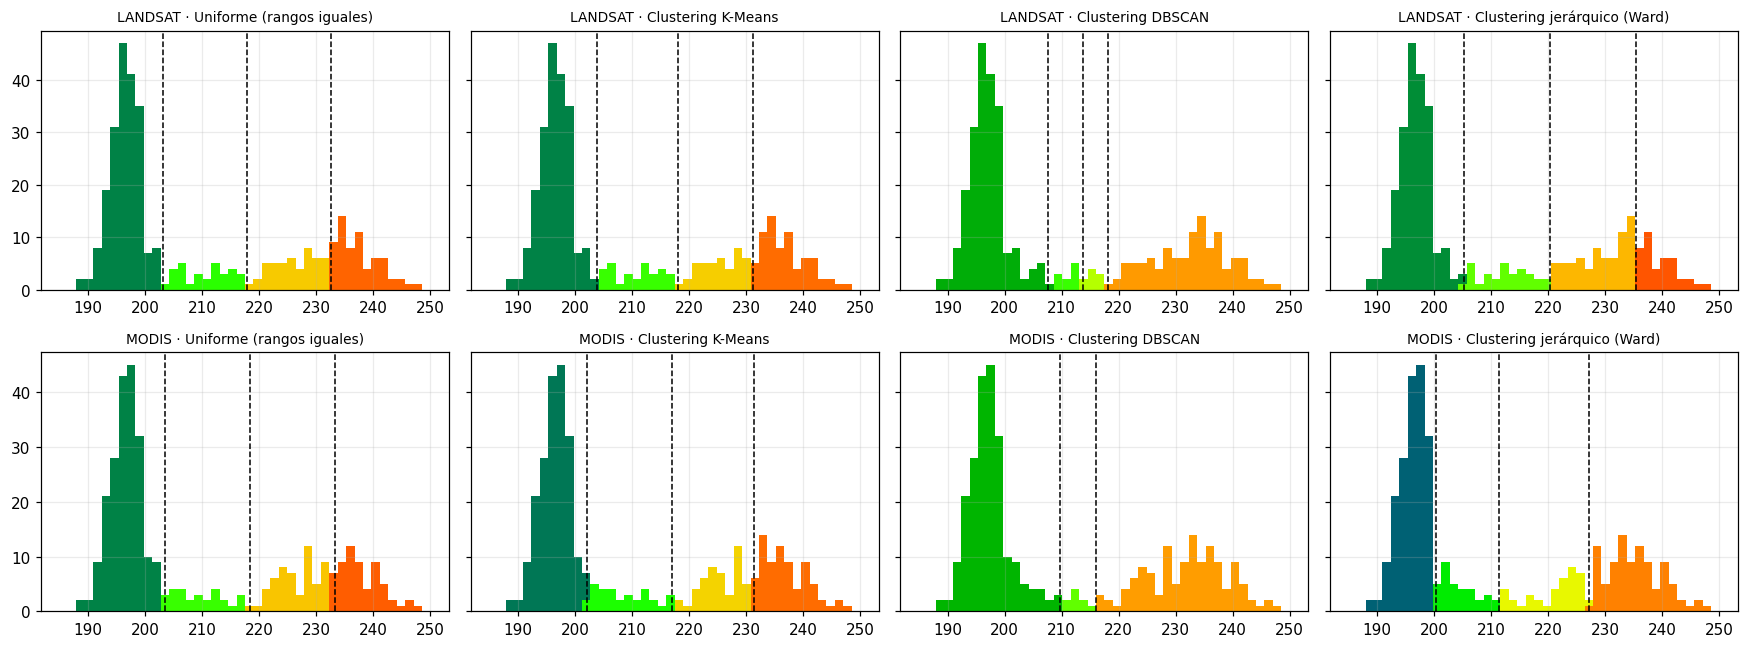

,dataset,discretizador,zonas,cortes,muestras_por_zona
0,landsat,uniform,4,"[203.2, 217.9, 232.6]","[201, 32, 50, 64]"
1,landsat,kmeans,4,"[203.9, 218.1, 231.2]","[202, 31, 43, 71]"
2,landsat,dbscan,4,"[207.6, 213.8, 218.1]","[212, 11, 10, 114]"
3,landsat,hierarchical,4,"[205.2, 220.3, 235.3]","[205, 31, 70, 41]"
4,modis,uniform,4,"[203.4, 218.3, 233.2]","[203, 29, 63, 61]"
5,modis,kmeans,4,"[202.2, 217.0, 231.4]","[199, 32, 51, 74]"
6,modis,dbscan,3,"[209.6, 216.0]","[219, 9, 128]"
7,modis,hierarchical,4,"[200.2, 211.4, 227.0]","[187, 34, 40, 95]"


In [18]:
from fkernel_lab.preprocessing import IrradianceDiscretizer, DISCRETIZERS, DISCRETIZER_LABELS
from fkernel_lab.experiment import holdout_split  # (el módulo se escribe más abajo; ya existe en el repositorio)

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey="row")
tabla = []
for r, (name, d) in enumerate(datasets.items()):
    tr, te = holdout_split(d)
    ytr = d.value.values[tr]
    for c, m in enumerate(DISCRETIZERS):
        disc = IrradianceDiscretizer(m, 4).fit(ytr)
        z = disc.transform(ytr)
        ax = axes[r, c]
        for k in range(disc.n_classes_):
            ax.hist(ytr[z == k], bins=np.linspace(185, 250, 45), color=CMAP((disc.zones()[k]["mid"] - vmin) / (vmax - vmin)))
        for cut in disc.cuts_:
            ax.axvline(cut, color="k", ls="--", lw=1)
        ax.set_title(f"{name.upper()} · {DISCRETIZER_LABELS[m]}", fontsize=9)
        tabla.append({"dataset": name, "discretizador": m, "zonas": disc.n_classes_,
                      "cortes": np.round(disc.cuts_, 1).tolist(), "muestras_por_zona": np.bincount(z).tolist()})
plt.tight_layout(); plt.show()
display(pd.DataFrame(tabla))

Cada discretizador define un problema de clasificación distinto: los rangos iguales y K‑Means dejan una zona baja
muy poblada (la moda costera) y zonas intermedias pequeñas; el jerárquico reparte de otra forma las zonas altas; y
DBSCAN, al buscar regiones densas, concentra casi todo en las dos modas y deja zonas intermedias diminutas (o solo 3
zonas en MODIS). Esto es clave para interpretar las métricas: **una accuracy alta con DBSCAN no significa que el
modelo distinga bien todas las zonas**.

### 4.3 Motor experimental
`experiment.py` define el espacio de configuraciones (`Spec`), construye cada pipeline de sklearn
(`escalador → reductor → modelo`), el objeto desplegable `IrradianceZoneModel` (discretizador + pipeline) y el
protocolo de evaluación que se explica en la sección 5.

In [19]:
%%writefile fkernel_lab/experiment.py
"""Motor experimental: espacio de pipelines, evaluación justa y modelo
desplegable (discretizador + pipeline)."""
import os
import time
import urllib.request
from itertools import product
from typing import NamedTuple

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             matthews_corrcoef, roc_auc_score)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, Normalizer, StandardScaler

from .estimators import KANNCVec, KSVCVec
from .kridge import KRidgeClassifier
from .kernels import KERNELS
from .preprocessing import DISCRETIZERS, DimReducer, IrradianceDiscretizer

SEED = 2021
N_ZONES = 4
FEATURES = ["latitude", "longitude", "band1", "band2", "band3", "band4", "band5", "band6", "band7"]
TARGET = "value"
DATA_URL = "https://raw.githubusercontent.com/magohector/fkernel/master/Experimentos/{}_model.csv"
DATASETS = ("landsat", "modis")

SCALERS = {"standard": StandardScaler, "minmax": MinMaxScaler, "normalizer": Normalizer}
REDUCERS = ("pca", "lda")
MODELS = ("ksvc", "kann", "kridge")
MODEL_LABELS = {"ksvc": "KSVC", "kann": "KANN", "kridge": "KRidgeClassifier"}

# Hiperparámetros por defecto de la ETAPA 1 (iguales para todos los kernels;
# la escala de cada kernel la fija la heurística de la mediana)
DEFAULT_PARAMS = {
    "ksvc": dict(C=10.0),
    "kann": dict(hidden_layer_sizes=(50,), activation="relu", alpha=1e-3,
                 learning_rate_init=0.01, max_iter=300, early_stopping=False,
                 n_components=80),
    "kridge": dict(alpha=0.1),
}


class Spec(NamedTuple):
    """Una combinación Escalador × Discretizador × Reductor × Modelo × Kernel."""
    scaler: str
    discretizer: str
    reducer: str
    model: str
    kernel: str

    @property
    def id(self):
        return "|".join(self)

    @classmethod
    def from_id(cls, text):
        return cls(*text.split("|"))


def all_specs(kernels=KERNELS):
    return [Spec(*c) for c in product(SCALERS, DISCRETIZERS, REDUCERS, MODELS, kernels)]


# ---------------------------------------------------------------------------
# Datos
# ---------------------------------------------------------------------------
def load_dataset(name, data_dir="data"):
    path = os.path.join(data_dir, f"{name}_model.csv")
    if not os.path.exists(path):
        os.makedirs(data_dir, exist_ok=True)
        urllib.request.urlretrieve(DATA_URL.format(name), path)
    df = pd.read_csv(path)
    df.attrs["name"] = name
    return df


def holdout_split(df, test_size=0.2, seed=SEED):
    """80/20 estratificado por quintiles de irradiancia (independiente del
    discretizador, para que TODOS los pipelines usen la misma partición)."""
    strata = pd.qcut(df[TARGET], 5, labels=False, duplicates="drop")
    return train_test_split(np.arange(len(df)), test_size=test_size,
                            random_state=seed, stratify=strata)


# ---------------------------------------------------------------------------
# Construcción de pipelines
# ---------------------------------------------------------------------------
def make_estimator(model, kernel, **params):
    p = {**DEFAULT_PARAMS[model], **params}
    if model == "ksvc":
        return KSVCVec(kernel=kernel, random_state=SEED, **p)
    if model == "kann":
        return KANNCVec(kernel=kernel, random_state=SEED, **p)
    if model == "kridge":
        return KRidgeClassifier(kernel=kernel, **p)
    raise ValueError(f"Modelo desconocido: {model!r}")


def make_pipeline(spec, **model_params):
    """Pipeline de sklearn sobre X. El discretizador actúa sobre y, por eso
    vive en ``IrradianceZoneModel`` y no dentro del Pipeline."""
    return Pipeline([
        ("scaler", SCALERS[spec.scaler]()),
        ("reducer", DimReducer(spec.reducer, random_state=SEED)),
        ("model", make_estimator(spec.model, spec.kernel, **model_params)),
    ])


def decision_scores(pipe, X):
    """Puntuaciones por clase (decision_function o predict_proba)."""
    if hasattr(pipe, "decision_function"):
        s = pipe.decision_function(X)
    else:
        s = pipe.predict_proba(X)
    s = np.asarray(s, dtype=float)
    if s.ndim == 1:
        s = np.column_stack([-s, s])
    return s


# ---------------------------------------------------------------------------
# Métricas
# ---------------------------------------------------------------------------
def ovr_auc(y_true, scores, classes):
    """AUC macro uno-contra-resto. Se calcula clase a clase con las
    puntuaciones crudas, así sirve para SVM/Ridge (no probabilísticos)."""
    vals = []
    for j, c in enumerate(classes):
        b = (np.asarray(y_true) == c).astype(int)
        if 0 < b.sum() < len(b):
            vals.append(roc_auc_score(b, scores[:, j]))
    return float(np.mean(vals)) if vals else np.nan


def compute_metrics(y_true, y_pred, scores, classes, n_classes):
    labels = np.arange(n_classes)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "auc": ovr_auc(y_true, scores, classes),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }


METRICS = ("accuracy", "f1", "auc", "mcc")


def selection_score(mcc, f1):
    """Criterio de selección: media de MCC y F1 macro.

    MCC resume toda la matriz de confusión, pero con zonas muy desbalanceadas
    (p. ej. DBSCAN crea zonas intermedias diminutas) puede ser alto aunque el
    modelo ignore las zonas pequeñas. F1 macro da el mismo peso a cada zona y
    penaliza ese comportamiento. Promediar ambos evita premiar esa trampa."""
    return (np.asarray(mcc) + np.asarray(f1)) / 2


def add_selection_score(df):
    df = df.copy()
    df["cv_score"] = selection_score(df["cv_mcc"], df["cv_f1"])
    df["test_score"] = selection_score(df["test_mcc"], df["test_f1"])
    return df


# ---------------------------------------------------------------------------
# Modelo desplegable
# ---------------------------------------------------------------------------
class IrradianceZoneModel:
    """Discretizador de irradiancia + pipeline (escalador, reductor, modelo)."""

    def __init__(self, spec, dataset, model_params=None, n_zones=N_ZONES):
        self.spec = spec if isinstance(spec, Spec) else Spec(*spec)
        self.dataset = dataset
        self.model_params = dict(model_params or {})
        self.n_zones = n_zones
        self.features = list(FEATURES)

    def fit(self, X, y_continuous):
        self.discretizer_ = IrradianceDiscretizer(self.spec.discretizer, self.n_zones).fit(y_continuous)
        labels = self.discretizer_.transform(y_continuous)
        self.pipeline_ = make_pipeline(self.spec, **self.model_params).fit(X, labels)
        self.classes_ = self.pipeline_.classes_
        return self

    def labels(self, y_continuous):
        return self.discretizer_.transform(y_continuous)

    def predict(self, X):
        return self.pipeline_.predict(np.asarray(X, dtype=float))

    def scores(self, X):
        return decision_scores(self.pipeline_, np.asarray(X, dtype=float))

    def zones(self):
        return self.discretizer_.zones()


# ---------------------------------------------------------------------------
# Evaluación justa
# ---------------------------------------------------------------------------
def make_cv(n_splits=5, n_repeats=2):
    return RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=SEED)


def evaluate_spec(spec, df, train_idx, test_idx, model_params=None, cv=None,
                  keep_predictions=False):
    """Evalúa una configuración con:
    1) discretizador ajustado SOLO con la irradiancia de entrenamiento,
    2) validación cruzada repetida y estratificada (mismas particiones para
       todos los pipelines con el mismo discretizador),
    3) ajuste final en el 80 % y medición en el holdout 20 % intacto."""
    cv = cv or make_cv()
    X = df[FEATURES].to_numpy(float)
    y = df[TARGET].to_numpy(float)
    Xtr, ytr, Xte, yte = X[train_idx], y[train_idx], X[test_idx], y[test_idx]

    model = IrradianceZoneModel(spec, df.attrs.get("name", ""), model_params)
    disc = IrradianceDiscretizer(spec.discretizer, model.n_zones).fit(ytr)
    ltr = disc.transform(ytr)
    k = disc.n_classes_
    template = make_pipeline(spec, **(model_params or {}))

    rows = []
    for fit_i, val_i in cv.split(Xtr, ltr):
        t0 = time.perf_counter()
        pipe = clone(template).fit(Xtr[fit_i], ltr[fit_i])
        t1 = time.perf_counter()
        pred = pipe.predict(Xtr[val_i])
        sc = decision_scores(pipe, Xtr[val_i])
        t2 = time.perf_counter()
        m = compute_metrics(ltr[val_i], pred, sc, pipe.classes_, k)
        m.update(fit_time=t1 - t0, score_time=t2 - t1)
        rows.append(m)
    cvdf = pd.DataFrame(rows)

    model.fit(Xtr, ytr)
    lte = model.labels(yte)
    pred = model.predict(Xte)
    sc = model.scores(Xte)
    hold = compute_metrics(lte, pred, sc, model.classes_, k)

    out = {"dataset": df.attrs.get("name", ""), **spec._asdict(), "spec_id": spec.id,
           "n_zones": k}
    for m in METRICS + ("fit_time", "score_time"):
        out[f"cv_{m}"] = float(cvdf[m].mean())
        out[f"cv_{m}_std"] = float(cvdf[m].std(ddof=1))
    for m in METRICS:
        out[f"test_{m}"] = float(hold[m])
    if keep_predictions:
        out["_model"] = model
        out["_y_true"] = lte
        out["_y_pred"] = pred
        out["_scores"] = sc
        out["_confusion"] = confusion_matrix(lte, pred, labels=np.arange(k))
    return out


def run_grid(datasets, specs, out_csv, split=None, model_params=None, verbose=True):
    """Evalúa todas las configuraciones y guarda cada fila en ``out_csv``.
    Es reanudable: si el CSV ya contiene una configuración, no se repite."""
    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev["dataset"], prev["spec_id"]))
    total = len(datasets) * len(specs)
    t0 = time.time()
    for name, df in datasets.items():
        tr, te = split[name] if split else holdout_split(df)
        for spec in specs:
            if (name, spec.id) in done:
                continue
            try:
                row = evaluate_spec(spec, df, tr, te, model_params)
                target = out_csv
            except Exception as exc:  # se registra aparte y se sigue
                row = {"dataset": name, "spec_id": spec.id, "error": repr(exc)}
                target = out_csv.replace(".csv", "_errors.csv")
            pd.DataFrame([row]).to_csv(target, mode="a", index=False,
                                       header=not os.path.exists(target))
            done.add((name, spec.id))
            if verbose and len(done) % 50 == 0:
                print(f"{len(done)}/{total} configuraciones · {time.time() - t0:.0f}s", flush=True)
    return pd.read_csv(out_csv)


# ---------------------------------------------------------------------------
# Etapa 2: sintonización de hiperparámetros de los mejores pipelines
# ---------------------------------------------------------------------------
BANDWIDTHS = [0.25, 0.35, 0.5, 0.7, 1.0, 1.4, 2.0, 2.8, 4.0]
PARAM_SPACE = {
    "ksvc": {"model__C": list(np.logspace(0, 5, 11)), "model__bandwidth": BANDWIDTHS,
             "model__class_weight": [None, "balanced"]},
    "kridge": {"model__alpha": list(np.logspace(-4, 2, 13)), "model__bandwidth": BANDWIDTHS,
               "model__class_weight": [None, "balanced"]},
    "kann": {"model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1], "model__bandwidth": BANDWIDTHS,
             "model__hidden_layer_sizes": [(25,), (50,), (100,), (50, 25)],
             "model__activation": ["relu", "tanh", "identity"]},
}


def tune_spec(spec, df, train_idx, n_iter=20, n_splits=5):
    """Búsqueda aleatoria (criterio: media de MCC y F1 macro) sobre el 80 % de entrenamiento.
    Devuelve los mejores parámetros del modelo (sin el prefijo model__)."""
    from sklearn.metrics import make_scorer
    from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

    X = df[FEATURES].to_numpy(float)[train_idx]
    y = df[TARGET].to_numpy(float)[train_idx]
    labels = IrradianceDiscretizer(spec.discretizer, N_ZONES).fit_transform(y)
    space = dict(PARAM_SPACE[spec.model])
    if spec.kernel == "linear":
        space.pop("model__bandwidth", None)
    if spec.kernel == "hyperbolic":
        space["model__coef0"] = [-1.0, -0.5, 0.0, 0.5]
    def _score(y_true, y_pred):
        return float(selection_score(matthews_corrcoef(y_true, y_pred),
                                     f1_score(y_true, y_pred, average="macro", zero_division=0)))

    search = RandomizedSearchCV(
        make_pipeline(spec), space, n_iter=n_iter, random_state=SEED,
        scoring=make_scorer(_score),
        cv=StratifiedKFold(n_splits, shuffle=True, random_state=SEED), error_score=np.nan)
    search.fit(X, labels)
    best = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    return best, float(search.best_score_)


# ---------------------------------------------------------------------------
# Exportación de modelos (artefacto que usa la aplicación web)
# ---------------------------------------------------------------------------
def _clean(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, tuple):
        return list(value)
    return value


def build_artifact(result, source="notebook"):
    """Empaqueta un resultado de ``evaluate_spec(keep_predictions=True)``."""
    import datetime
    model = result["_model"]
    spec = model.spec
    meta = {
        "dataset": result["dataset"],
        "spec": spec._asdict(),
        "spec_id": spec.id,
        "label": f"{result['dataset'].upper()} · {MODEL_LABELS[spec.model]} · {spec.kernel} "
                 f"({spec.scaler}/{spec.discretizer}/{spec.reducer})",
        "params": {k: _clean(v) for k, v in model.model_params.items()},
        "kernel_params": {k: _clean(v) for k, v in
                          getattr(model.pipeline_.named_steps["model"], "kernel_params_", {}).items()},
        "cv": {m: result[f"cv_{m}"] for m in METRICS},
        "cv_std": {m: result[f"cv_{m}_std"] for m in METRICS},
        "test": {m: result[f"test_{m}"] for m in METRICS},
        "cv_score": float(selection_score(result["cv_mcc"], result["cv_f1"])),
        "fit_time": result["cv_fit_time"],
        "confusion": result["_confusion"].tolist(),
        "zones": model.zones(),
        "created_at": datetime.datetime.now().isoformat(timespec="seconds"),
        "source": source,
    }
    return {"model": model, "meta": meta}


def save_artifact(artifact, models_dir="models", name=None):
    import joblib
    import re
    os.makedirs(models_dir, exist_ok=True)
    meta = artifact["meta"]
    slug = name or re.sub(r"[^a-z0-9]+", "-", f"{meta['dataset']}-{meta['spec_id']}".lower()).strip("-")
    path = os.path.join(models_dir, f"{slug}.joblib")
    meta["id"] = slug
    joblib.dump(artifact, path, compress=3)
    return path

Overwriting fkernel_lab/experiment.py


In [20]:
import importlib, fkernel_lab.experiment as E
importlib.reload(E)
from fkernel_lab.experiment import (Spec, all_specs, make_pipeline, evaluate_spec, run_grid, tune_spec,
                                    add_selection_score, build_artifact, save_artifact, METRICS, MODEL_LABELS,
                                    FEATURES, DEFAULT_PARAMS, make_cv)
specs = all_specs()
print(f"Pipelines por satélite: {len(specs)}  ·  total: {2 * len(specs)}")
display(pd.DataFrame([s._asdict() for s in specs]).nunique().to_frame("opciones").T)
print("Hiperparámetros por defecto (etapa 1):", DEFAULT_PARAMS)
make_pipeline(Spec("minmax", "kmeans", "lda", "ksvc", "rquadratic"))

Pipelines por satélite: 648  ·  total: 1296


,scaler,discretizer,reducer,model,kernel
opciones,3,4,2,3,9


Hiperparámetros por defecto (etapa 1): {'ksvc': {'C': 10.0}, 'kann': {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.01, 'max_iter': 300, 'early_stopping': False, 'n_components': 80}, 'kridge': {'alpha': 0.1}}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('reducer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,method,'lda'
,random_state,2021
,C,10.0
,kernel,'rquadratic'


---
## 5. Evaluación justa de los pipelines

**Protocolo (idéntico para las 1 296 configuraciones):**
1. **Partición fija 80/20** por satélite (semilla 2021), estratificada por quintiles de irradiancia. Es independiente
   del discretizador, así que *todos* los pipelines de un satélite usan exactamente los mismos datos de entrenamiento y
   el mismo holdout.
2. El discretizador se ajusta **solo** con la irradiancia del 80 %.
3. **Validación cruzada estratificada y repetida** (5 pliegues × 2 repeticiones) sobre el 80 %: 10 ajustes por
   pipeline, con los mismos pliegues para todos los pipelines que comparten discretizador. Se reporta media y
   desviación.
4. Ajuste final en todo el 80 % y medición en el **holdout del 20 %**, que no se usa para seleccionar nada.
5. Etapa 1 con hiperparámetros por defecto comunes (KSVC C=10; KRidge α=0.1; KANN 50 neuronas ReLU) y escala de
   kernel calibrada por la mediana. Etapa 2: sintonización de los mejores candidatos.

**Métricas.**
* **Accuracy**: proporción de aciertos (sensible al desbalance).
* **F1 macro**: media del F1 de cada zona; todas las zonas pesan igual.
* **AUC OvR macro**: área bajo la curva ROC uno‑contra‑resto por zona, calculada con las puntuaciones del modelo
  (`decision_function` o `predict_proba`), promediada.
* **MCC** (Matthews): correlación entre zona real y predicha usando toda la matriz de confusión.

**Criterio de selección = (MCC + F1 macro) / 2 en validación cruzada.** MCC por sí solo premia a DBSCAN, que crea
zonas intermedias casi vacías; añadir F1 macro exige acertar también en las zonas pequeñas.

In [21]:
t0 = time.time()
cache = Path("results/grid_results.csv")
if RECALCULAR and cache.exists():
    cache.unlink()
grid = run_grid(datasets, specs, str(cache), verbose=True)     # reanudable: solo evalúa lo que falte
grid = add_selection_score(grid)
errores = Path("results/grid_results_errors.csv")
print(f"Resultados: {len(grid)} configuraciones · errores: "
      f"{len(pd.read_csv(errores)) if errores.exists() else 0} · {time.time() - t0:.1f}s")

Resultados: 1296 configuraciones · errores: 0 · 0.0s


### 5.1 Mejores pipelines de la etapa 1

In [22]:
cols = ["spec_id", "n_zones", "cv_score", "cv_accuracy", "cv_f1", "cv_auc", "cv_mcc", "cv_mcc_std",
        "test_accuracy", "test_f1", "test_auc", "test_mcc", "cv_fit_time"]
for name in datasets:
    g = grid[grid.dataset == name].sort_values("cv_score", ascending=False)
    print(f"\n=== {name.upper()}: 10 mejores de {len(g)} (orden por (MCC+F1)/2 en validación cruzada) ===")
    display(g[cols].head(10).style.background_gradient(subset=["cv_score", "test_mcc"], cmap="Greens")
            .format(precision=3).hide(axis="index"))


=== LANDSAT: 10 mejores de 648 (orden por (MCC+F1)/2 en validación cruzada) ===


spec_id,n_zones,cv_score,cv_accuracy,cv_f1,cv_auc,cv_mcc,cv_mcc_std,test_accuracy,test_f1,test_auc,test_mcc,cv_fit_time
normalizer|hierarchical|lda|ksvc|triangle,4,0.713,0.837,0.701,0.917,0.724,0.098,0.828,0.692,0.937,0.710,0.009
minmax|hierarchical|lda|ksvc|rbf,4,0.711,0.843,0.688,0.901,0.733,0.070,0.782,0.594,0.903,0.635,0.019
standard|hierarchical|lda|ksvc|rbf,4,0.711,0.843,0.688,0.901,0.733,0.070,0.782,0.594,0.903,0.635,0.009
minmax|hierarchical|lda|kridge|rbf,4,0.700,0.836,0.680,0.928,0.720,0.066,0.793,0.615,0.934,0.656,0.013
standard|hierarchical|lda|kridge|rbf,4,0.700,0.836,0.680,0.928,0.720,0.066,0.793,0.615,0.934,0.656,0.010
standard|hierarchical|lda|ksvc|rquadratic,4,0.698,0.834,0.678,0.903,0.718,0.087,0.782,0.610,0.936,0.631,0.010
minmax|hierarchical|lda|ksvc|rquadratic,4,0.698,0.834,0.678,0.903,0.718,0.087,0.782,0.610,0.936,0.631,0.018
normalizer|hierarchical|lda|kridge|rquadratic,4,0.697,0.831,0.681,0.930,0.713,0.087,0.805,0.671,0.922,0.674,0.010
minmax|hierarchical|lda|kridge|rquadratic,4,0.692,0.828,0.675,0.921,0.709,0.077,0.793,0.620,0.927,0.654,0.009
standard|hierarchical|lda|kridge|rquadratic,4,0.692,0.828,0.675,0.921,0.709,0.077,0.793,0.620,0.927,0.654,0.012



=== MODIS: 10 mejores de 648 (orden por (MCC+F1)/2 en validación cruzada) ===


spec_id,n_zones,cv_score,cv_accuracy,cv_f1,cv_auc,cv_mcc,cv_mcc_std,test_accuracy,test_f1,test_auc,test_mcc,cv_fit_time
standard|dbscan|lda|kann|rbf,3,0.796,0.947,0.699,0.954,0.892,0.039,0.899,0.621,0.974,0.803,0.149
standard|dbscan|lda|kann|poly,3,0.790,0.942,0.697,0.956,0.884,0.040,0.899,0.621,0.969,0.803,0.159
minmax|dbscan|lda|kann|poly,3,0.790,0.942,0.697,0.956,0.884,0.040,0.899,0.621,0.969,0.803,0.192
minmax|dbscan|lda|kann|rbf,3,0.790,0.944,0.692,0.953,0.887,0.035,0.910,0.698,0.974,0.826,0.145
standard|dbscan|lda|kann|hyperbolic,3,0.786,0.940,0.692,0.952,0.879,0.047,0.899,0.621,0.950,0.803,0.186
normalizer|dbscan|lda|kann|linear,3,0.785,0.949,0.672,0.961,0.898,0.027,0.921,0.714,0.976,0.848,0.131
minmax|dbscan|lda|kann|hyperbolic,3,0.784,0.938,0.691,0.952,0.877,0.047,0.899,0.621,0.950,0.803,0.202
normalizer|dbscan|lda|kann|triangle,3,0.783,0.945,0.676,0.968,0.890,0.044,0.933,0.781,0.983,0.870,0.164
minmax|dbscan|lda|ksvc|rquadratic,3,0.781,0.951,0.663,0.837,0.900,0.034,0.921,0.633,0.712,0.850,0.008
standard|dbscan|lda|ksvc|rquadratic,3,0.781,0.951,0.663,0.837,0.900,0.034,0.921,0.633,0.712,0.850,0.007


Nota: con LDA, `StandardScaler` y `MinMaxScaler` producen resultados idénticos (LDA es invariante a
transformaciones afines de cada variable), por eso aparecen parejas empatadas.

### 5.2 ¿Qué componente influye más?

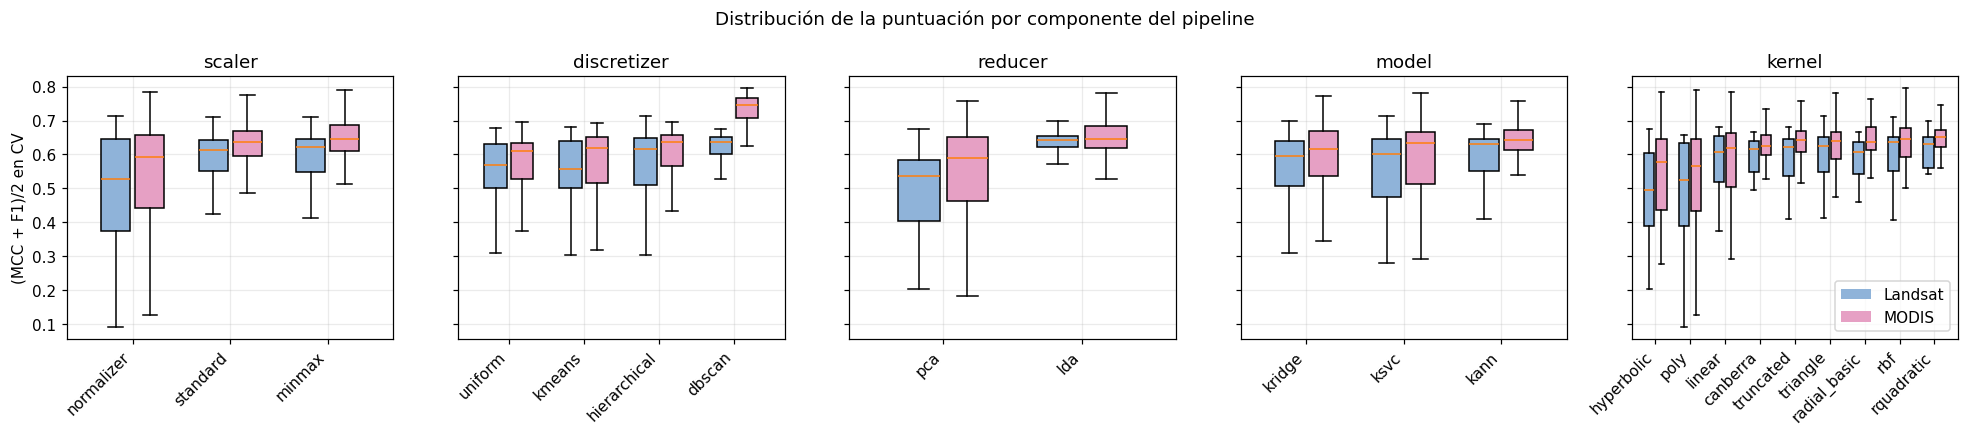

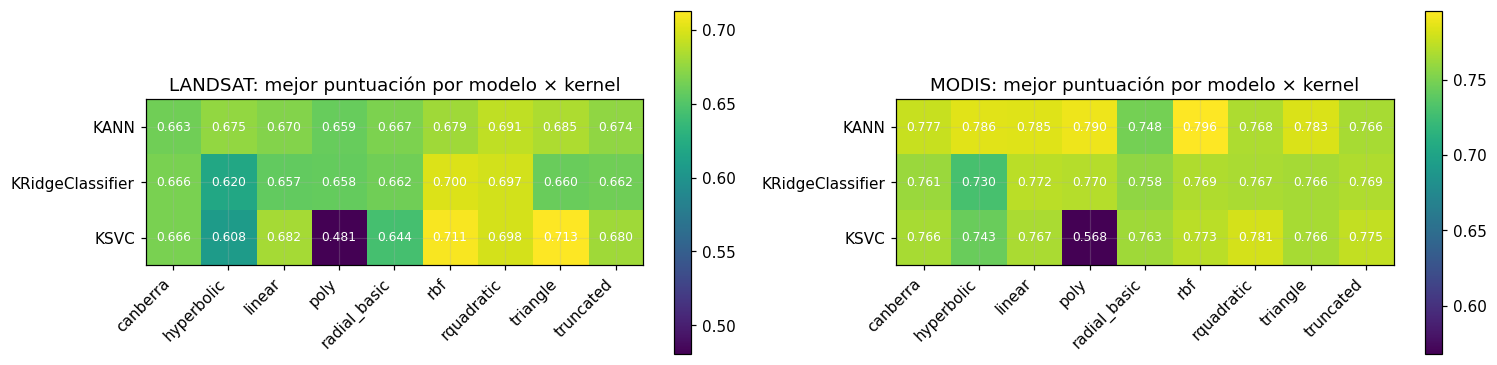

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, comp in zip(axes, ["scaler", "discretizer", "reducer", "model", "kernel"]):
    order = grid.groupby(comp)["cv_score"].median().sort_values().index
    data = [[grid[(grid[comp] == o) & (grid.dataset == n)]["cv_score"].values for o in order] for n in datasets]
    pos = np.arange(len(order))
    for i, (n, dd) in enumerate(zip(datasets, data)):
        b = ax.boxplot(dd, positions=pos + (i - 0.5) * 0.35, widths=0.3, patch_artist=True, showfliers=False)
        for p in b["boxes"]:
            p.set_facecolor(["#8fb3d9", "#e6a0c4"][i])
    ax.set_xticks(pos); ax.set_xticklabels(order, rotation=45, ha="right"); ax.set_title(comp)
axes[0].set_ylabel("(MCC + F1)/2 en CV")
axes[-1].legend([plt.Rectangle((0, 0), 1, 1, fc=c) for c in ["#8fb3d9", "#e6a0c4"]], ["Landsat", "MODIS"])
plt.suptitle("Distribución de la puntuación por componente del pipeline"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, name in zip(axes, datasets):
    pv = grid[grid.dataset == name].pivot_table(index="model", columns="kernel", values="cv_score", aggfunc="max")
    im = ax.imshow(pv.values, cmap="viridis"); ax.set_title(f"{name.upper()}: mejor puntuación por modelo × kernel")
    ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels(pv.columns, rotation=45, ha="right")
    ax.set_yticks(range(pv.shape[0])); ax.set_yticklabels([MODEL_LABELS[m] for m in pv.index])
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            ax.text(j, i, f"{pv.values[i, j]:.3f}", ha="center", va="center", color="w", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

### 5.3 La trampa del desbalance: por qué no seleccionar solo por accuracy o MCC
Cada punto es un pipeline. Con DBSCAN la accuracy y el MCC son altos, pero el F1 macro es bajo: el modelo acierta las
dos zonas grandes e ignora las intermedias.

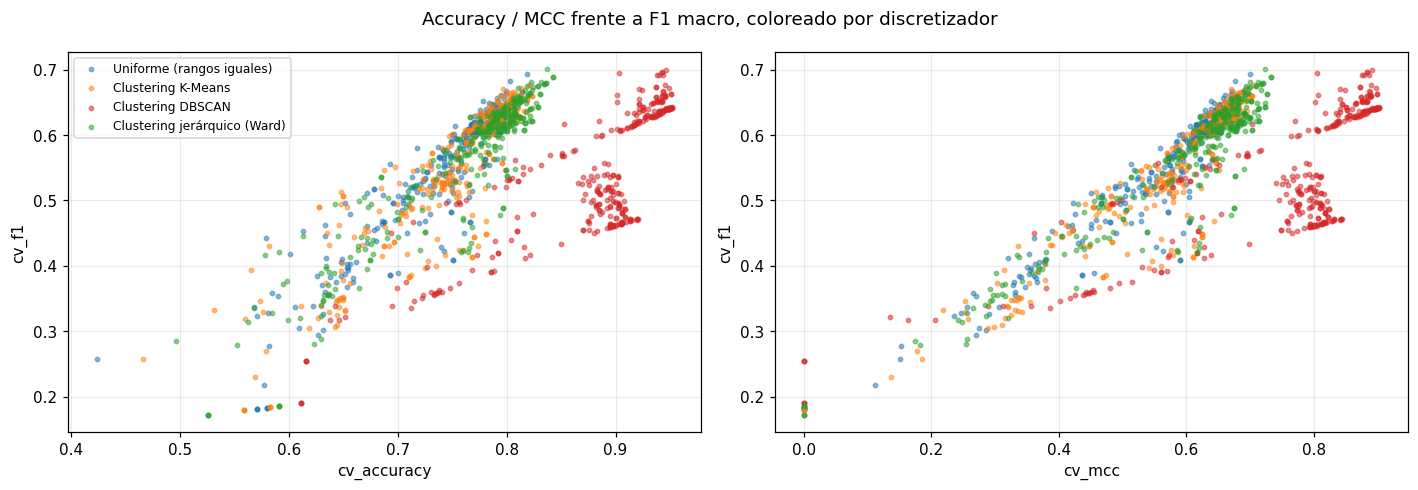

,cv_accuracy,cv_mcc,cv_f1,cv_auc,cv_score
discretizer,,,,,
dbscan,0.8784,0.7522,0.5363,0.8332,0.6442
hierarchical,0.7597,0.5912,0.5606,0.8532,0.5759
kmeans,0.7458,0.5662,0.5429,0.8415,0.5545
uniform,0.7401,0.5546,0.5462,0.8468,0.5504


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (x, y) in zip(axes, [("cv_accuracy", "cv_f1"), ("cv_mcc", "cv_f1")]):
    for disc, color in zip(DISCRETIZERS, ["tab:blue", "tab:orange", "tab:red", "tab:green"]):
        s = grid[grid.discretizer == disc]
        ax.scatter(s[x], s[y], s=8, alpha=0.5, color=color, label=DISCRETIZER_LABELS[disc])
    ax.set(xlabel=x, ylabel=y)
axes[0].legend(fontsize=8); plt.suptitle("Accuracy / MCC frente a F1 macro, coloreado por discretizador")
plt.tight_layout(); plt.show()
display(grid.groupby("discretizer")[["cv_accuracy", "cv_mcc", "cv_f1", "cv_auc", "cv_score"]].mean())

### 5.4 Comparación estadística de kernels y modelos (Friedman + Nemenyi)
Para decidir si las diferencias entre kernels son reales y no fruto del azar, se aplica el **test de Friedman**:
cada *bloque* es una combinación fija (satélite, escalador, discretizador, reductor, modelo) y los *tratamientos* son
los 9 kernels. Se ordenan los kernels dentro de cada bloque (1 = mejor) y se promedian los rangos. La **distancia
crítica de Nemenyi** $CD=q_\alpha\sqrt{k(k+1)/(6N)}$ indica qué diferencias de rango medio son significativas al 5 %.
Lo mismo se hace con los 3 modelos.

kernel: rango medio
kernel
rquadratic     3.5500
rbf            3.7200
truncated      4.4200
triangle       4.4300
canberra       4.9400
radial_basic   5.0500
linear         5.4700
poly           6.3600
hyperbolic     7.0600

model: rango medio
model
kann     1.7400
ksvc     2.1200
kridge   2.1400



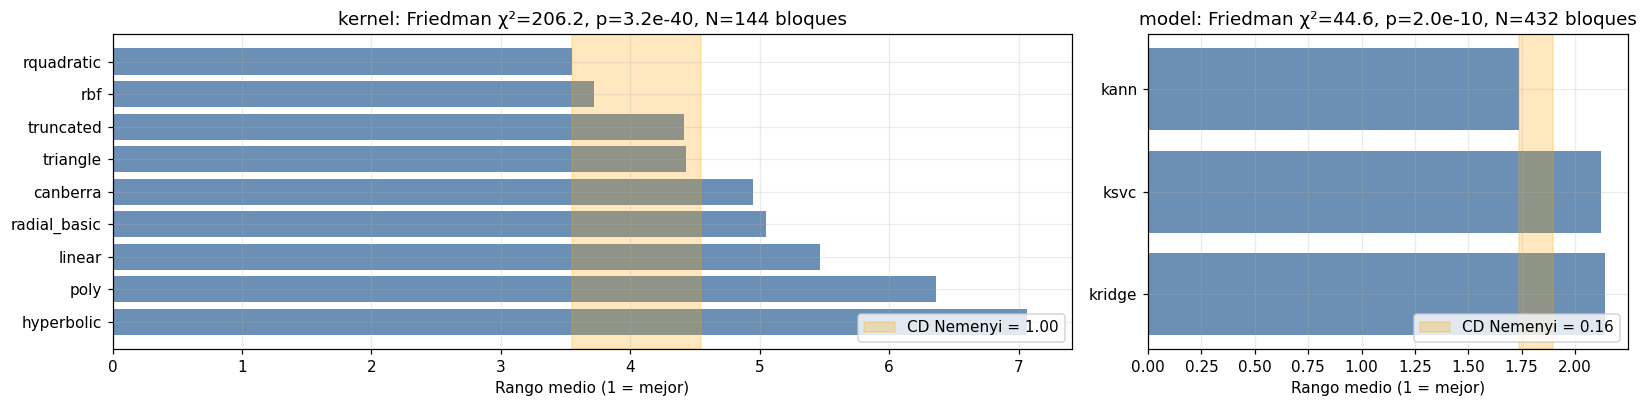

In [25]:
from scipy.stats import friedmanchisquare
Q05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102}

def friedman(factor):
    bloques = [c for c in ["dataset", "scaler", "discretizer", "reducer", "model", "kernel"] if c != factor]
    pv = grid.pivot_table(index=bloques, columns=factor, values="cv_score").dropna()
    stat, p = friedmanchisquare(*[pv[c] for c in pv.columns])
    ranks = pv.rank(axis=1, ascending=False).mean().sort_values()
    k, n = pv.shape[1], pv.shape[0]
    cd = Q05[k] * np.sqrt(k * (k + 1) / (6 * n))
    return ranks, stat, p, cd, n

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8), gridspec_kw={"width_ratios": [2, 1]})
for ax, factor in zip(axes, ["kernel", "model"]):
    ranks, stat, p, cd, n = friedman(factor)
    ax.barh(ranks.index, ranks.values, color="#6b8fb5")
    best = ranks.iloc[0]
    ax.axvspan(best, best + cd, color="orange", alpha=0.25, label=f"CD Nemenyi = {cd:.2f}")
    ax.invert_yaxis(); ax.set_xlabel("Rango medio (1 = mejor)")
    ax.set_title(f"{factor}: Friedman χ²={stat:.1f}, p={p:.1e}, N={n} bloques"); ax.legend(loc="lower right")
    print(f"{factor}: rango medio\n{ranks.round(2).to_string()}\n")
plt.tight_layout(); plt.show()

Los kernels cuyo rango medio cae dentro de la banda naranja (a menos de una distancia crítica del mejor) no son
estadísticamente distinguibles de él; los que quedan fuera son significativamente peores.

### 5.5 Coste computacional

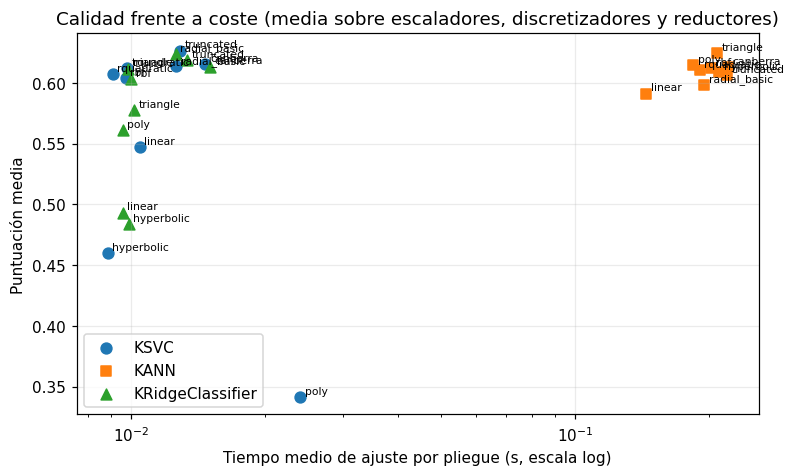

In [26]:
t = grid.groupby(["model", "kernel"])[["cv_fit_time", "cv_score"]].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, mk in zip(["ksvc", "kann", "kridge"], ["o", "s", "^"]):
    s = t[t.model == m]
    ax.scatter(s.cv_fit_time, s.cv_score, marker=mk, s=50, label=MODEL_LABELS[m])
    for _, r in s.iterrows():
        ax.annotate(r.kernel, (r.cv_fit_time, r.cv_score), fontsize=7, xytext=(3, 2), textcoords="offset points")
ax.set(xscale="log", xlabel="Tiempo medio de ajuste por pliegue (s, escala log)", ylabel="Puntuación media",
       title="Calidad frente a coste (media sobre escaladores, discretizadores y reductores)")
ax.legend(); plt.show()

### 5.6 Etapa 2: sintonización de hiperparámetros
Se toman, para cada satélite y cada modelo, los **2 mejores pipelines distintos** de la etapa 1 (12 en total; los
empates exactos Standard/MinMax con LDA cuentan como uno) y se hace una **búsqueda aleatoria** de 20 combinaciones
con validación cruzada estratificada de 5 pliegues **dentro del 80 % de entrenamiento**, con el mismo criterio
(MCC + F1)/2:

| Modelo | Espacio de búsqueda |
|---|---|
| KSVC | C ∈ 10⁰…10⁵ (como el artículo), `bandwidth` ∈ 0.25…4, `class_weight` ∈ {None, balanced} |
| KRidge | α ∈ 10⁻⁴…10², `bandwidth`, `class_weight` |
| KANN | α ∈ 10⁻⁵…10⁻¹, capas ocultas, activación, `bandwidth` |

Después, cada candidato sintonizado se re‑evalúa con **exactamente el mismo protocolo** de la etapa 1 (CV 5×2 +
holdout), de modo que las cifras antes y después son comparables.

In [27]:
def candidatos(g, por_modelo=2):
    g = g.sort_values("cv_score", ascending=False)
    g = g.drop_duplicates(subset=["dataset", "model", "cv_score", "test_score"])  # empates Standard/MinMax+LDA
    return g.groupby(["dataset", "model"]).head(por_modelo)

cand = candidatos(grid)
tuning_cache = Path("results/tuning_results.json")
tuned = json.loads(tuning_cache.read_text()) if tuning_cache.exists() and not RECALCULAR else {}
t0 = time.time()
for _, row in cand.iterrows():
    key = f"{row.dataset}|{row.spec_id}"
    if key in tuned:
        continue
    d = datasets[row.dataset]; tr, te = holdout_split(d)
    best, score = tune_spec(Spec.from_id(row.spec_id), d, tr, n_iter=20)
    tuned[key] = {"params": {k: (list(v) if isinstance(v, tuple) else (v.item() if hasattr(v, "item") else v))
                             for k, v in best.items()}, "search_score": score}
    tuning_cache.write_text(json.dumps(tuned, indent=1))
    print(f"{key}: {tuned[key]}")
print(f"Sintonización: {time.time() - t0:.0f}s")

def params_de(key):
    p = dict(tuned[key]["params"])
    if "hidden_layer_sizes" in p:
        p["hidden_layer_sizes"] = tuple(p["hidden_layer_sizes"])
    return p

finales = []
for _, row in cand.iterrows():
    d = datasets[row.dataset]; tr, te = holdout_split(d)
    spec = Spec.from_id(row.spec_id); key = f"{row.dataset}|{row.spec_id}"
    res = evaluate_spec(spec, d, tr, te, model_params=params_de(key), keep_predictions=True)
    res["params"] = params_de(key)
    res["etapa1_cv_score"] = row.cv_score; res["etapa1_test_mcc"] = row.test_mcc
    finales.append(res)
fin = add_selection_score(pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in finales]))
fin["mejora_cv"] = fin.cv_score - fin.etapa1_cv_score
display(fin[["dataset", "spec_id", "params", "etapa1_cv_score", "cv_score", "mejora_cv", "cv_accuracy", "cv_f1",
             "cv_auc", "cv_mcc", "test_accuracy", "test_f1", "test_auc", "test_mcc"]]
        .sort_values(["dataset", "cv_score"], ascending=[True, False]).style.format(precision=3)
        .background_gradient(subset=["mejora_cv"], cmap="RdYlGn", vmin=-0.05, vmax=0.05).hide(axis="index"))

Sintonización: 0s


dataset,spec_id,params,etapa1_cv_score,cv_score,mejora_cv,cv_accuracy,cv_f1,cv_auc,cv_mcc,test_accuracy,test_f1,test_auc,test_mcc
landsat,normalizer|hierarchical|lda|kann|rquadratic,"{'hidden_layer_sizes': (50,), 'bandwidth': 0.7, 'alpha': 0.1, 'activation': 'tanh'}",0.691,0.703,0.013,0.831,0.692,0.938,0.714,0.793,0.647,0.938,0.665
landsat,standard|hierarchical|lda|kridge|rbf,"{'class_weight': None, 'bandwidth': 0.7, 'alpha': 3.1622776601683795}",0.700,0.702,0.001,0.838,0.678,0.930,0.725,0.782,0.605,0.928,0.634
landsat,minmax|hierarchical|lda|ksvc|rbf,"{'class_weight': None, 'bandwidth': 2.8, 'C': 100.0}",0.711,0.701,-0.010,0.834,0.683,0.879,0.718,0.782,0.606,0.882,0.633
landsat,normalizer|hierarchical|lda|kridge|rquadratic,"{'class_weight': 'balanced', 'bandwidth': 1.0, 'alpha': 0.03162277660168379}",0.697,0.693,-0.004,0.810,0.695,0.914,0.691,0.759,0.615,0.909,0.624
landsat,normalizer|hierarchical|lda|kann|triangle,"{'hidden_layer_sizes': (25,), 'bandwidth': 0.7, 'alpha': 0.1, 'activation': 'tanh'}",0.685,0.692,0.007,0.824,0.683,0.929,0.701,0.793,0.629,0.937,0.654
landsat,normalizer|hierarchical|lda|ksvc|triangle,"{'class_weight': None, 'bandwidth': 0.7, 'C': 3.1622776601683795}",0.713,0.689,-0.024,0.827,0.673,0.919,0.705,0.816,0.678,0.927,0.691
modis,standard|dbscan|lda|ksvc|truncated,"{'class_weight': 'balanced', 'bandwidth': 2.8, 'C': 10.0}",0.775,0.779,0.004,0.919,0.713,0.912,0.845,0.899,0.725,0.954,0.812
modis,standard|dbscan|lda|kann|poly,"{'hidden_layer_sizes': (100,), 'bandwidth': 4.0, 'alpha': 0.001, 'activation': 'tanh'}",0.790,0.779,-0.011,0.948,0.663,0.965,0.895,0.921,0.708,0.969,0.850
modis,standard|dbscan|lda|kann|rbf,"{'hidden_layer_sizes': (50,), 'bandwidth': 0.7, 'alpha': 0.1, 'activation': 'tanh'}",0.796,0.778,-0.018,0.948,0.662,0.964,0.894,0.921,0.714,0.972,0.848
modis,standard|dbscan|lda|kridge|poly,"{'class_weight': None, 'bandwidth': 2.8, 'alpha': 31.622776601683793}",0.770,0.776,0.006,0.955,0.644,0.946,0.908,0.921,0.633,0.920,0.850


### 5.7 Selección final
Para cada satélite y modelo se elige el candidato con mayor puntuación en CV; si la sintonización no mejoró la
puntuación de la etapa 1, se conservan los hiperparámetros por defecto. **El holdout solo se usa para reportar.**

In [28]:
sel = []
for r in finales:
    key = f"{r['dataset']}|{r['spec_id']}"
    score_t = float(E.selection_score(r["cv_mcc"], r["cv_f1"]))
    if score_t + 1e-9 < r["etapa1_cv_score"]:          # la sintonización no ayudó: parámetros por defecto
        d = datasets[r["dataset"]]; tr, te = holdout_split(d)
        r = evaluate_spec(Spec.from_id(r["spec_id"]), d, tr, te, keep_predictions=True) | {"params": {}}
        score_t = float(E.selection_score(r["cv_mcc"], r["cv_f1"]))
    r["cv_score"] = score_t
    sel.append(r)
sel_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in sel])
idx = sel_df.sort_values("cv_score", ascending=False).groupby(["dataset", "model"]).head(1).index
mejores = [sel[i] for i in idx]
mejores.sort(key=lambda r: (r["dataset"], -r["cv_score"]))
tabla_final = pd.DataFrame([{"dataset": r["dataset"], "modelo": MODEL_LABELS[r["model"]], "pipeline": r["spec_id"],
                             "params": r["params"], "CV (MCC+F1)/2": r["cv_score"],
                             **{f"holdout {m}": r[f"test_{m}"] for m in METRICS}} for r in mejores])
display(tabla_final.style.format(precision=3).hide(axis="index"))

dataset,modelo,pipeline,params,CV (MCC+F1)/2,holdout accuracy,holdout f1,holdout auc,holdout mcc
landsat,KSVC,normalizer|hierarchical|lda|ksvc|triangle,{},0.713,0.828,0.692,0.937,0.710
landsat,KANN,normalizer|hierarchical|lda|kann|rquadratic,"{'hidden_layer_sizes': (50,), 'bandwidth': 0.7, 'alpha': 0.1, 'activation': 'tanh'}",0.703,0.793,0.647,0.938,0.665
landsat,KRidgeClassifier,standard|hierarchical|lda|kridge|rbf,"{'class_weight': None, 'bandwidth': 0.7, 'alpha': 3.1622776601683795}",0.702,0.782,0.605,0.928,0.634
modis,KANN,standard|dbscan|lda|kann|rbf,{},0.796,0.899,0.621,0.974,0.803
modis,KSVC,standard|dbscan|lda|ksvc|rquadratic,{},0.781,0.921,0.633,0.712,0.850
modis,KRidgeClassifier,standard|dbscan|lda|kridge|poly,"{'class_weight': None, 'bandwidth': 2.8, 'alpha': 31.622776601683793}",0.776,0.921,0.633,0.920,0.850


### 5.8 Matrices de confusión (holdout) de los pipelines seleccionados

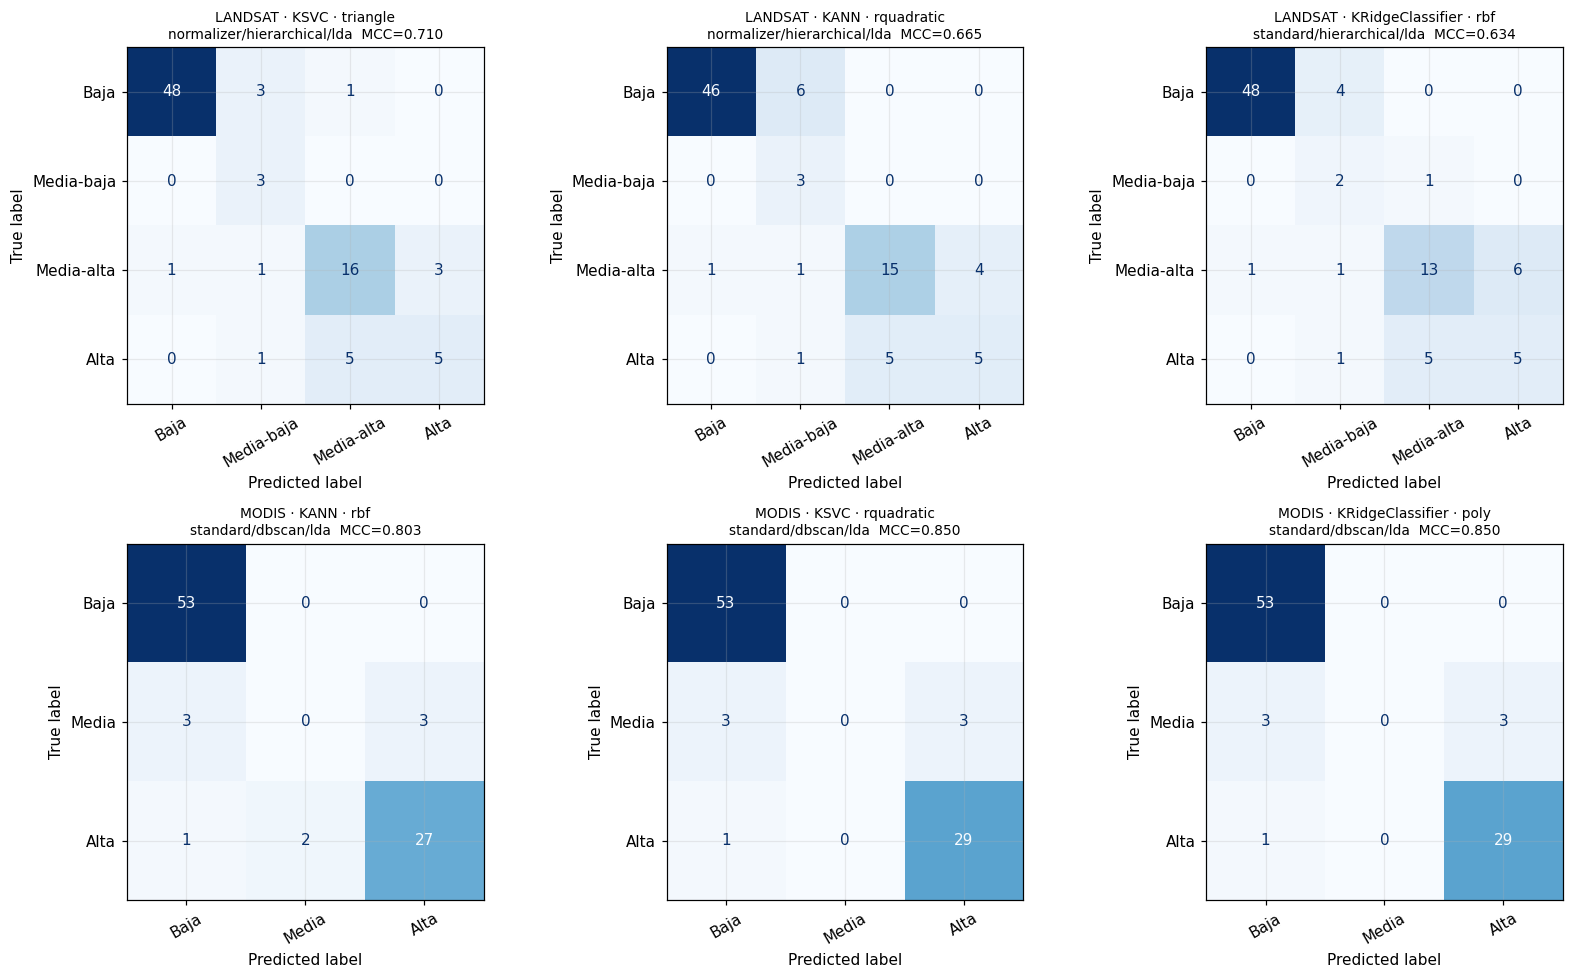

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, r in zip(axes.ravel(), mejores):
    names = [z["name"] for z in r["_model"].zones()]
    ConfusionMatrixDisplay(r["_confusion"], display_labels=names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{r['dataset'].upper()} · {MODEL_LABELS[r['model']]} · {r['kernel']}\n"
                 f"{r['scaler']}/{r['discretizer']}/{r['reducer']}  MCC={r['test_mcc']:.3f}", fontsize=9)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 5.9 ¿Curva ROC o curva precisión‑recall?
La curva ROC usa la tasa de falsos positivos, cuyo denominador es el total de negativos. Cuando una zona es muy
minoritaria frente a las demás, miles de verdaderos negativos hacen que la FPR apenas crezca y la ROC luce optimista.
La curva **precisión‑recall** no usa los verdaderos negativos y revela esos errores. Regla aplicada: se calcula la
razón de desbalance del holdout (zona más grande / zona más pequeña); **si es ≥ 3 se usa precisión‑recall**, si no, ROC.
Se muestra la curva por zona (uno‑contra‑resto) del mejor pipeline de cada satélite, con la línea de referencia de
un clasificador aleatorio (la prevalencia en PR, la diagonal en ROC).

landsat: se usa precisión‑recall
modis: se usa precisión‑recall


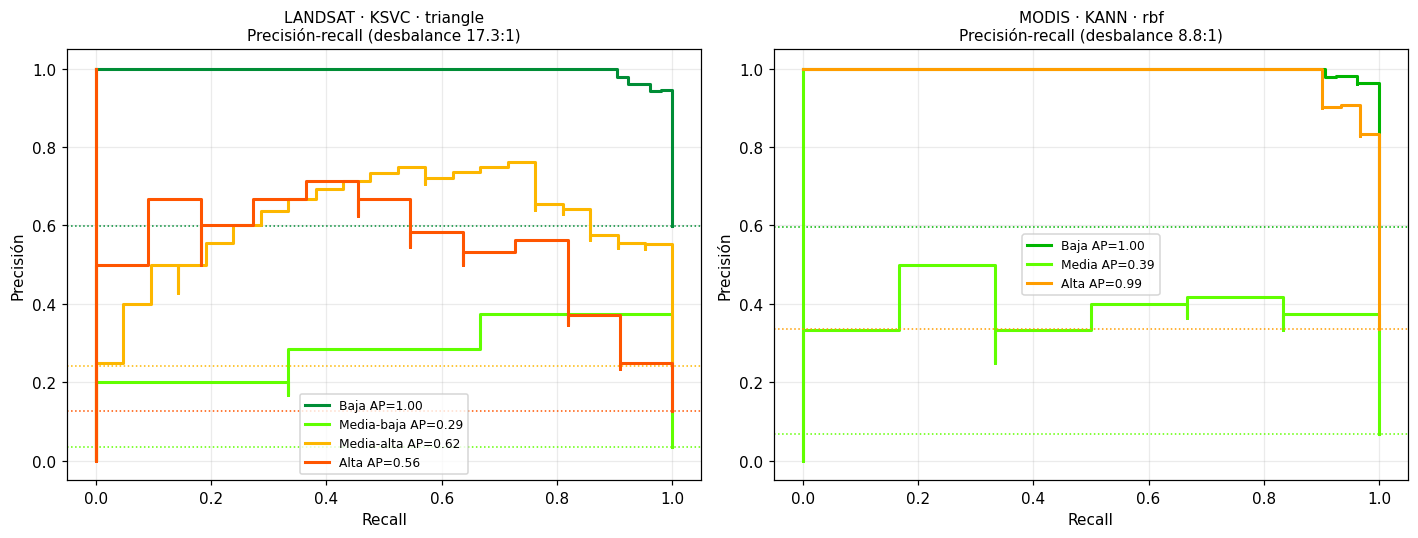

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

def curva(r, ax):
    y, s, classes = r["_y_true"], r["_scores"], r["_model"].classes_
    zonas = r["_model"].zones()
    counts = np.bincount(y, minlength=len(zonas)); counts = counts[counts > 0]
    ratio = counts.max() / counts.min()
    usar_pr = ratio >= 3
    for j, c in enumerate(classes):
        b = (y == c).astype(int)
        if b.sum() in (0, len(b)):
            continue
        col = CMAP((zonas[c]["mid"] - vmin) / (vmax - vmin))
        if usar_pr:
            p, rc, _ = precision_recall_curve(b, s[:, j])
            ax.step(rc, p, where="post", color=col, lw=2, label=f"{zonas[c]['name']} AP={average_precision_score(b, s[:, j]):.2f}")
            ax.axhline(b.mean(), color=col, ls=":", lw=1)
        else:
            f, t, _ = roc_curve(b, s[:, j])
            ax.plot(f, t, color=col, lw=2, label=f"{zonas[c]['name']} AUC={roc_auc_score(b, s[:, j]):.2f}")
    if usar_pr:
        ax.set(xlabel="Recall", ylabel="Precisión", title=f"Precisión‑recall (desbalance {ratio:.1f}:1)")
    else:
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos", title=f"ROC (desbalance {ratio:.1f}:1)")
    ax.legend(fontsize=8)
    return usar_pr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, datasets):
    r = next(m for m in mejores if m["dataset"] == name)   # el mejor del satélite
    pr = curva(r, ax)
    ax.set_title(f"{name.upper()} · {MODEL_LABELS[r['model']]} · {r['kernel']}\n" + ax.get_title(), fontsize=10)
    print(f"{name}: se usa {'precisión‑recall' if pr else 'ROC'}")
plt.tight_layout(); plt.show()

### 5.10 Mapas de zonas predichas
Los modelos se aplican sobre una malla regular de 2 km que cubre Nariño; las bandas en cada celda se estiman por
IDW a partir de las observaciones del mismo satélite (es lo mismo que hace la aplicación web). El color es el punto
medio del rango de la zona.

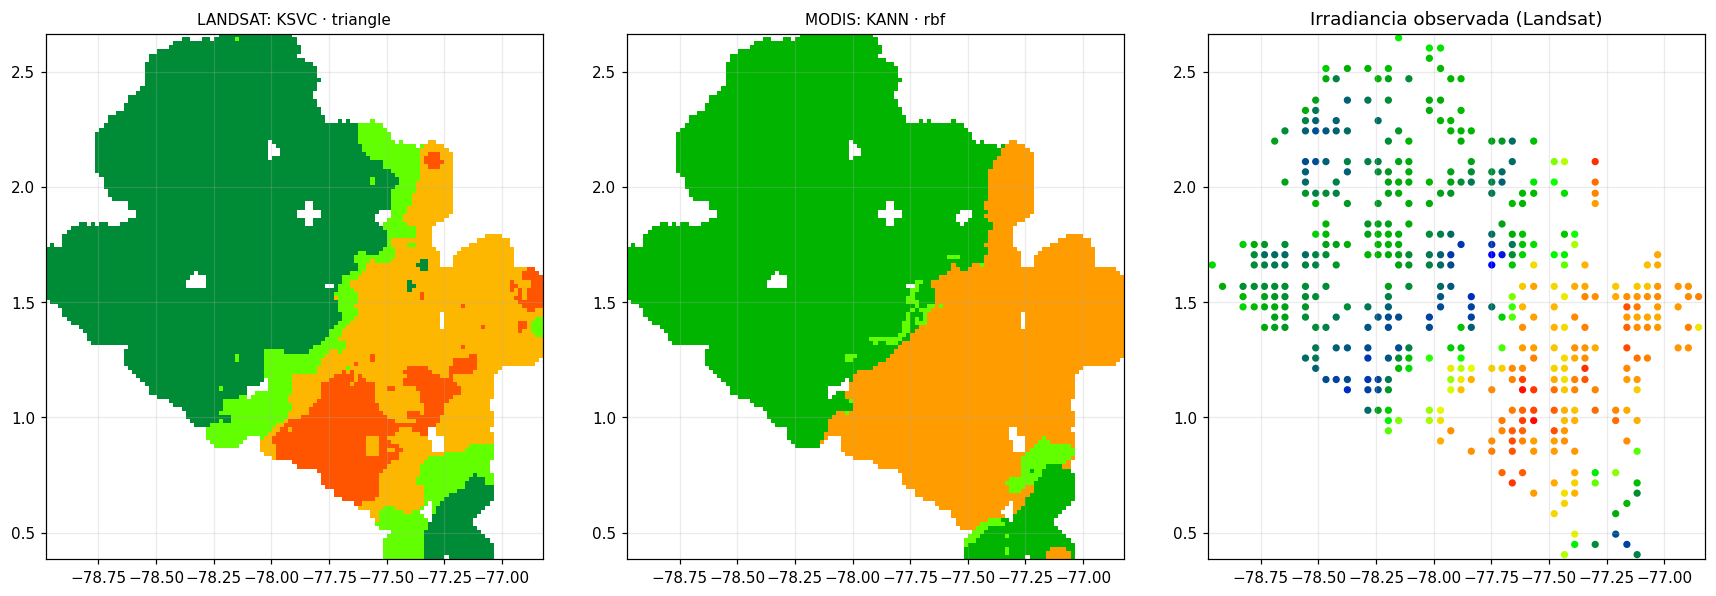

In [31]:
from fkernel_lab.geo import StudyGrid, SpectralField
malla = StudyGrid(list(datasets.values()), step=2000, max_dist=10000)
lon0, lat0 = merc_to_lonlat(malla.xs[0], malla.ys[-1]); lon1, lat1 = merc_to_lonlat(malla.xs[-1], malla.ys[0])
fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, name in zip(axes[:2], datasets):
    r = next(m for m in mejores if m["dataset"] == name)
    feats, _ = SpectralField(datasets[name]).features_at(malla.x, malla.y)
    mids = np.array([z["mid"] for z in r["_model"].zones()])[r["_model"].predict(feats)]
    ax.imshow(malla.to_image(mids), cmap=CMAP, vmin=vmin, vmax=vmax, extent=[lon0, lon1, lat0, lat1])
    ax.set_title(f"{name.upper()}: {MODEL_LABELS[r['model']]} · {r['kernel']}", fontsize=10)
lon, lat = merc_to_lonlat(landsat.latitude, landsat.longitude)
axes[2].scatter(lon, lat, c=landsat.value, cmap=CMAP, vmin=vmin, vmax=vmax, s=14)
axes[2].set_title("Irradiancia observada (Landsat)")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlim(lon0, lon1); ax.set_ylim(lat0, lat1)
plt.tight_layout(); plt.show()

---
## 6. Exportación de los mejores pipelines para la aplicación web
Se exportan dos grupos de modelos:
* **Mejor pipeline de cada modelo** (KSVC, KANN y KRidge) en cada satélite, tras la selección de la etapa 2.
* **Mejor pipeline de cada discretizador** en cada satélite (etapa 1, parámetros por defecto), si no está ya en el
  grupo anterior. Como cada discretizador define zonas distintas, así la aplicación puede comparar, por ejemplo,
  Landsat contra MODIS con el mismo esquema de 4 zonas, y no solo el esquema de 3 zonas de DBSCAN que domina MODIS.

Cada archivo `.joblib` contiene el `IrradianceZoneModel` ajustado con el 80 % de entrenamiento y sus metadatos:
configuración, hiperparámetros, métricas de CV y holdout, matriz de confusión y rangos de las zonas. La aplicación
(`app/app.py`) los registra automáticamente en su base de datos SQLite al arrancar.

In [32]:
import glob
for f in glob.glob("models/*.joblib"):
    if "-web-" not in f:            # los entrenados desde la web se conservan
        os.remove(f)
if Path("models/registry.db").exists():
    Path("models/registry.db").unlink()   # se reconstruye al arrancar la app

exportar = list(mejores)
ya = {(r["dataset"], r["spec_id"]) for r in exportar}
for name in datasets:
    d = datasets[name]; tr, te = holdout_split(d)
    top = grid[grid.dataset == name].sort_values("cv_score", ascending=False).groupby("discretizer").head(1)
    for _, row in top.iterrows():
        if (name, row.spec_id) not in ya and not any(r["dataset"] == name and r["discretizer"] == row.discretizer
                                                     for r in mejores):
            res = evaluate_spec(Spec.from_id(row.spec_id), d, tr, te, keep_predictions=True)
            res["params"] = {}
            exportar.append(res); ya.add((name, row.spec_id))

filas = []
for r in exportar:
    r["_model"].model_params = r["params"]
    path = save_artifact(build_artifact(r, source="notebook"), "models")
    filas.append({"archivo": path, "zonas": r["n_zones"], "CV (MCC+F1)/2": float(E.selection_score(r["cv_mcc"], r["cv_f1"])),
                  "holdout MCC": r["test_mcc"], "holdout F1": r["test_f1"]})
display(pd.DataFrame(filas).style.format(precision=3).hide(axis="index"))

# comprobación: se cargan desde disco usando solo la librería
art = joblib.load(path)
print(art["meta"]["label"], "->", art["model"].predict(datasets[art["meta"]["dataset"]][FEATURES].values[:5]))

archivo,zonas,CV (MCC+F1)/2,holdout MCC,holdout F1
models/landsat-normalizer-hierarchical-lda-ksvc-triangle.joblib,4,0.713,0.710,0.692
models/landsat-normalizer-hierarchical-lda-kann-rquadratic.joblib,4,0.703,0.665,0.647
models/landsat-standard-hierarchical-lda-kridge-rbf.joblib,4,0.702,0.634,0.605
models/modis-standard-dbscan-lda-kann-rbf.joblib,3,0.796,0.803,0.621
models/modis-standard-dbscan-lda-ksvc-rquadratic.joblib,3,0.781,0.850,0.633
models/modis-standard-dbscan-lda-kridge-poly.joblib,3,0.776,0.850,0.633
models/landsat-minmax-kmeans-lda-ksvc-linear.joblib,4,0.682,0.714,0.681
models/landsat-standard-uniform-lda-ksvc-linear.joblib,4,0.677,0.696,0.700
models/landsat-normalizer-dbscan-lda-kann-hyperbolic.joblib,4,0.675,0.795,0.459
models/modis-minmax-uniform-pca-ksvc-truncated.joblib,4,0.697,0.753,0.743


MODIS · KSVC · triangle (normalizer/kmeans/lda) -> [1 0 0 0 0]


## Conclusiones

1. **Funciones kernel.** La comparación es estadísticamente significativa (Friedman χ² ≈ 206, p ≈ 3·10⁻⁴⁰ sobre
   144 bloques). Los kernels con mejor rango medio son el **cuadrático racional** y el **rbf**. Los siguen el
   truncado, el triangular, Canberra y el radial básico. Los peores son el lineal, el polinómico y la **tangente
   hiperbólica**, que no es definida positiva y es muy sensible a su escala. Esto coincide con el artículo de
   referencia, donde rbf, radial básico y cuadrático racional encabezan la comparación. Gracias a la calibración
   por la mediana, los kernels alternativos (truncado, triangular, Canberra) compiten de igual a igual con el rbf.
2. **Modelos.** KANN obtiene el mejor rango medio (Friedman p ≈ 2·10⁻¹⁰), aunque es unas 15 veces más lento de
   entrenar. KSVC y KRidgeClassifier quedan empatados en promedio, pero **el mejor pipeline de Landsat es un
   KSVC** (kernel triangular) y KRidge queda a muy poca distancia con un coste mínimo. El truco kernel en
   RidgeClassifier es, por tanto, una alternativa competitiva y muy barata.
3. **Reductor.** LDA supera claramente a PCA en ambos satélites. A igual número de dimensiones, proyectar según la
   separabilidad entre zonas conserva lo que importa para clasificar.
4. **Escalador.** StandardScaler y MinMaxScaler son equivalentes; con LDA dan resultados idénticos, porque LDA es
   invariante a transformaciones afines. Normalizer es el peor en promedio (hunde a PCA), pero combinado con LDA
   funciona bien. Al normalizar cada fila dominan las coordenadas, y LDA reescala después las bandas
   comprimidas. Por eso el mejor pipeline de Landsat usa Normalizer.
5. **Discretizador y métricas.** DBSCAN produce las cifras más altas de accuracy y MCC, pero crea zonas
   intermedias casi vacías y, en MODIS, solo 3 zonas: es un problema más fácil, no un mejor modelo. Su F1 macro lo
   delata. Por ello se seleccionó con (MCC + F1)/2. Entre los esquemas de 4 zonas, el **clustering jerárquico** es
   el mejor en Landsat y el **uniforme** en MODIS. La accuracy sola no es un criterio adecuado con estas clases
   desbalanceadas; con esa razón de desbalance, la curva precisión‑recall resultó más informativa que la ROC.
6. **Satélites.** MODIS alcanza puntuaciones más altas que Landsat, en parte por el esquema de 3 zonas de DBSCAN.
   Con 4 zonas ambos quedan en un rango parecido: CV (MCC+F1)/2 ≈ 0.70 y MCC en holdout entre 0.63 y 0.75.
7. **Sintonización.** La búsqueda aleatoria mejoró poco o nada la puntuación en la validación 5×2: la
   calibración por la mediana ya deja los kernels en una escala adecuada. En varios casos la configuración
   sintonizada empeoró al re‑evaluarla con otras particiones (sobreajuste a la búsqueda), y se conservaron los
   parámetros por defecto.
8. **Mapas.** Todos los modelos reproducen el patrón geográfico conocido: irradiancia baja en la llanura pacífica
   y alta en la zona andina oriental. Las diferencias entre modelos se concentran en la franja de transición, que
   es donde están las zonas intermedias minoritarias.


---
**Punto 5.** La aplicación web está en `app/`. Instrucciones de despliegue (local, Docker, Render) en `README.md`.